# Telecom Retention Campaign Analysis using Causal Inference

## Business Problem

Telecom companies spend significant resources on customer retention campaigns. However, customers receiving retention offers are not selected randomly, leading to selection bias when evaluating campaign effectiveness.

The objective of this project is to estimate the true causal impact of retention offers on customer churn using multiple causal inference techniques.

---

## Objectives

- Explore customer and campaign data
- Estimate overall treatment effect
- Compare multiple causal inference methods
- Identify customer segments
- Estimate heterogeneous treatment effects
- Evaluate financial impact
- Provide business recommendations

In [106]:
# Uncomment only if running in Google Colab

# !pip install -q dowhy

In [107]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from dowhy import CausalModel

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [108]:
plt.style.use("default")

mpl.rcParams.update({

    "figure.dpi":300,
    "savefig.dpi":300,

    "figure.facecolor":"white",
    "axes.facecolor":"white",

    "font.family":"DejaVu Sans",

    "axes.titlesize":20,
    "axes.titleweight":"bold",

    "axes.labelsize":15,

    "xtick.labelsize":12,
    "ytick.labelsize":12,

    "legend.fontsize":12,

    "axes.spines.top":False,
    "axes.spines.right":False,

    "axes.linewidth":1.2,

    "grid.alpha":0.25

})

In [109]:
DATA_PATH = "/content/drive/MyDrive/Telecom_Causal_Inference_Modified_Data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {df.shape}")

display(df.head())

Dataset Shape : (7043, 46)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Original_Churn,Original_Churn_Flag,Month_to_Month_Flag,Fiber_Flag,Electronic_Check_Flag,No_OnlineSecurity_Flag,No_TechSupport_Flag,High_ARPU_Flag,Low_Tenure_Flag,Medium_Tenure_Flag,Risk_Segment,True_Propensity,Received_Offer,Churn_Probability_No_Offer,Churn_Probability_With_Offer,True_Treatment_Effect,Churn_Final_Flag,Churn_Final,Offer_Cost,Customer_Value,Expected_Revenue_Saved,Expected_Net_Value,Estimated_Propensity,ps_clip,ipw_weight
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,No,0,1,0,1,1,1,0,1,0,Medium Risk,0.768525,0,0.417949,0.292949,-0.125000,0,No,0.0,350.0,0.0,0.0,0.710231,0.710231,3.451030
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,No,0,0,0,0,0,1,0,0,1,Low Risk,0.167982,1,0.065107,0.040107,-0.025000,0,No,10.0,500.0,12.5,2.5,0.218878,0.218878,4.568746
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Yes,1,1,0,0,0,1,0,1,0,Medium Risk,0.668188,1,0.261304,0.136304,-0.125000,0,No,10.0,500.0,62.5,52.5,0.691720,0.691720,1.445671
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,No,0,0,0,0,0,0,0,0,0,Low Risk,0.167982,0,0.031322,0.010000,-0.021322,0,No,0.0,350.0,0.0,0.0,0.107681,0.107681,1.120675
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Yes,1,1,1,1,1,1,1,1,0,High Risk,0.920000,1,0.749435,0.479435,-0.270000,1,Yes,10.0,500.0,135.0,125.0,0.916231,0.916231,1.091428


In [110]:
missing = (
    df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing[missing>0])

print(f"Total Missing Values : {missing.sum()}")

,0


Total Missing Values : 0


In [111]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

TREATMENT = "Received_Offer"

OUTCOME = "Churn_Final_Flag"

In [112]:
print("Treatment Distribution")

display(
    df[TREATMENT]
    .value_counts()
    .rename_axis("Treatment")
    .reset_index(name="Customers")
)

print()

print("Outcome Distribution")

display(
    df[OUTCOME]
    .value_counts()
    .rename_axis("Outcome")
    .reset_index(name="Customers")
)

Treatment Distribution


,Treatment,Customers
0,1,3960
1,0,3083



Outcome Distribution


,Outcome,Customers
0,0,5470
1,1,1573


In [113]:
overview = pd.DataFrame({

    "Variable":[
        "Total Customers",
        "Features",
        "Treatment Variable",
        "Outcome Variable",
        "Treatment Rate",
        "Observed Churn Rate"
    ],

    "Value":[

        len(df),

        df.shape[1],

        TREATMENT,

        OUTCOME,

        round(df[TREATMENT].mean(),4),

        round(df[OUTCOME].mean(),4)

    ]

})

display(overview)

,Variable,Value
0,Total Customers,7043
1,Features,46
2,Treatment Variable,Received_Offer
3,Outcome Variable,Churn_Final_Flag
4,Treatment Rate,0.5623
5,Observed Churn Rate,0.2233


In [114]:
BASELINE_COLS = [

    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"

]

BASELINE_COLS = [

    col

    for col in BASELINE_COLS

    if col in df.columns

]

print(BASELINE_COLS)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [115]:
BUSINESS_COLS = [

    "Customer_Value",

    "Offer_Cost",

    "Expected_Revenue_Saved",

    "Expected_Net_Value",

    "True_Treatment_Effect"

]

print(df[BUSINESS_COLS].head())

   Customer_Value  Offer_Cost  Expected_Revenue_Saved  Expected_Net_Value  \
0           350.0         0.0                     0.0                 0.0   
1           500.0        10.0                    12.5                 2.5   
2           500.0        10.0                    62.5                52.5   
3           350.0         0.0                     0.0                 0.0   
4           500.0        10.0                   135.0               125.0   

   True_Treatment_Effect  
0              -0.125000  
1              -0.025000  
2              -0.125000  
3              -0.021322  
4              -0.270000  


# 2. Exploratory Data Analysis

Before estimating causal effects, it is important to understand the characteristics of the customer base and the distribution of treatment and outcome variables.

This section explores:

- Customer churn
- Retention offer distribution
- Customer demographics
- Service characteristics
- Financial variables
- Relationship between important numerical variables

,Churn,Customers
0,No,5470
1,Yes,1573


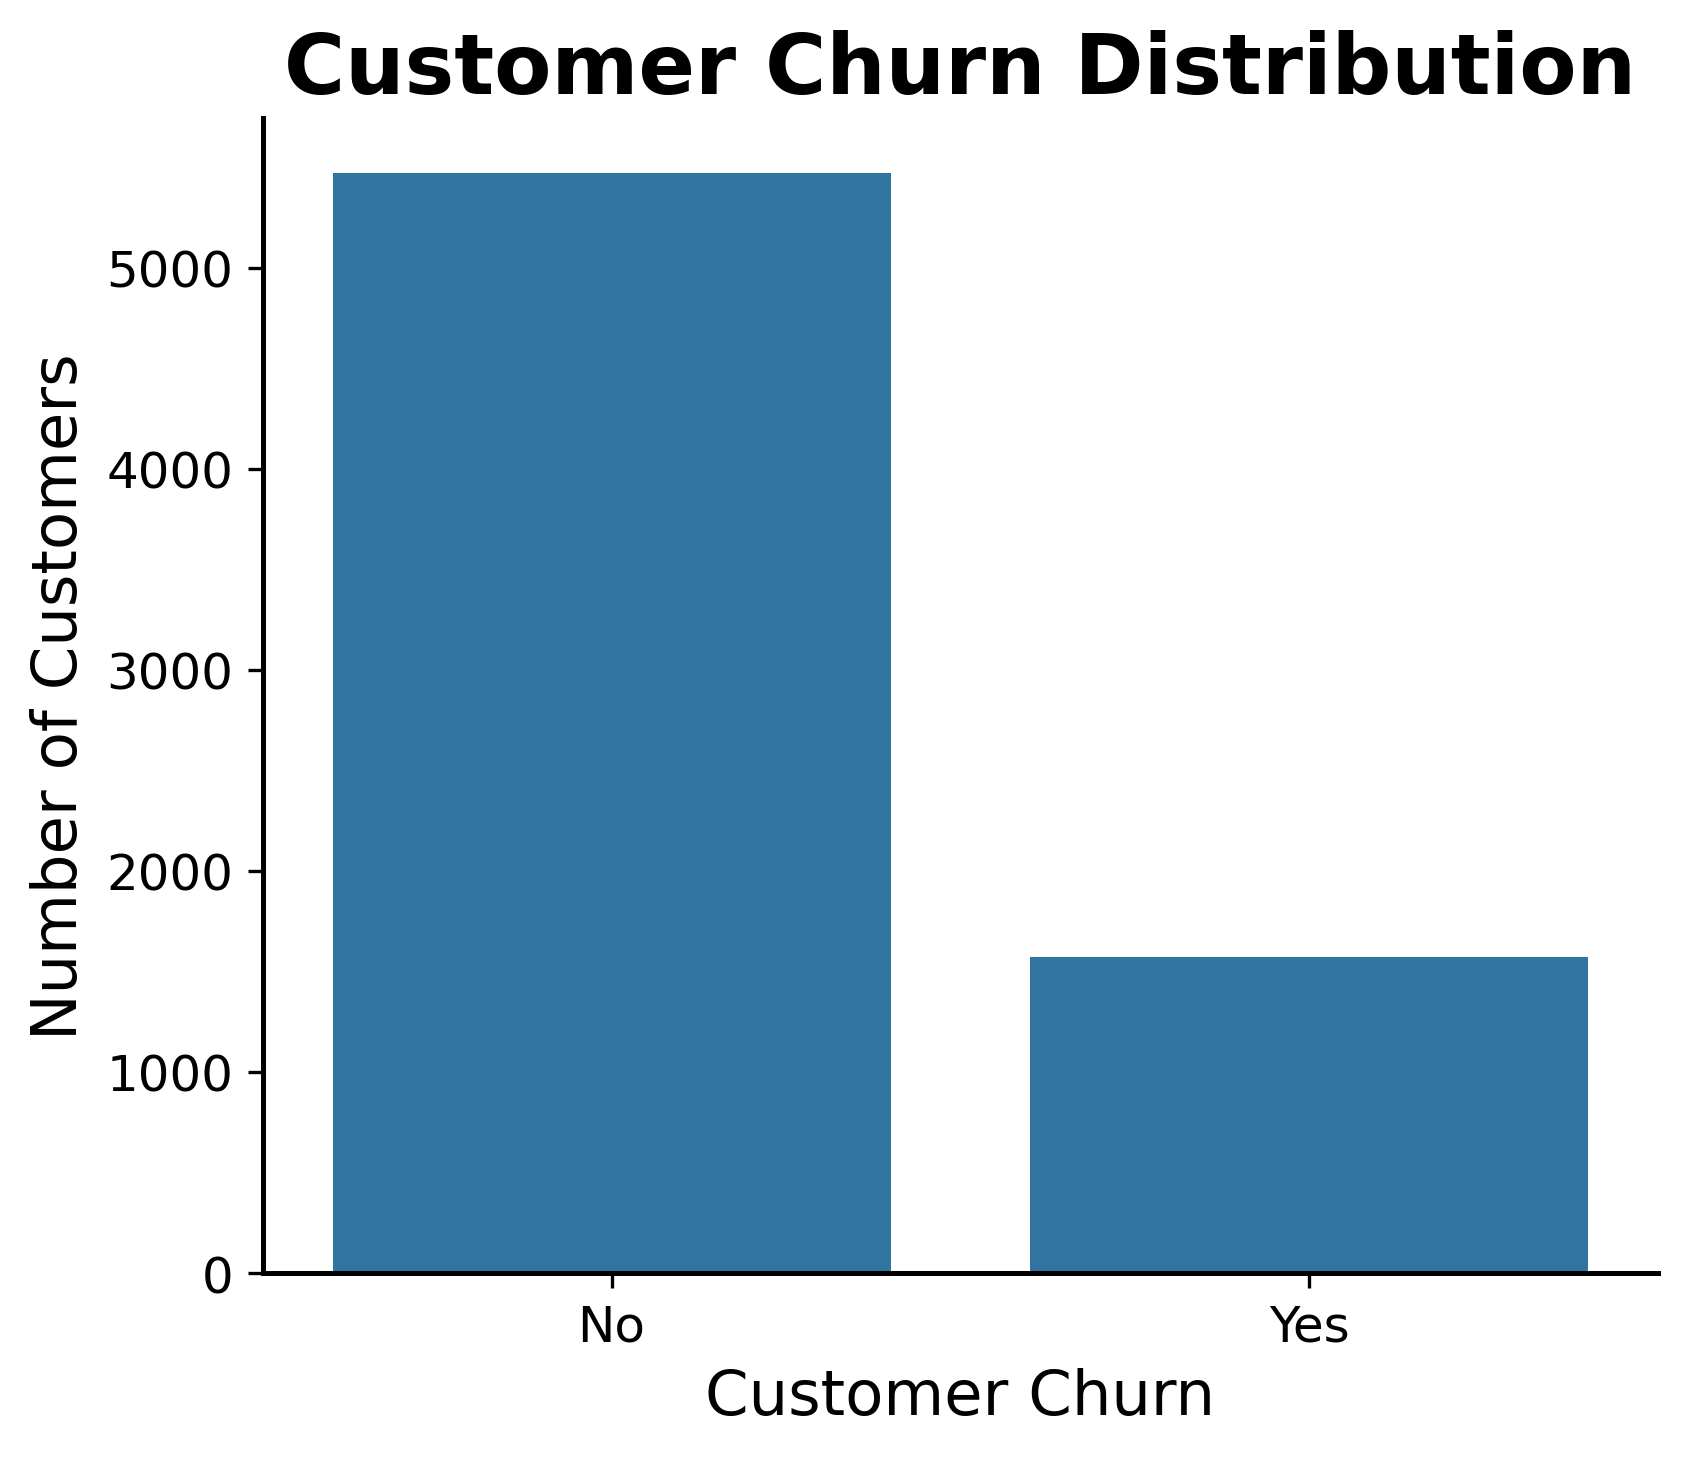

In [116]:
churn_counts = (
    df["Churn_Final"]
    .value_counts()
    .reset_index()
)

churn_counts.columns = ["Churn", "Customers"]

display(churn_counts)

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn_Final"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

plt.show()

,Received Offer,Customers
0,1,3960
1,0,3083


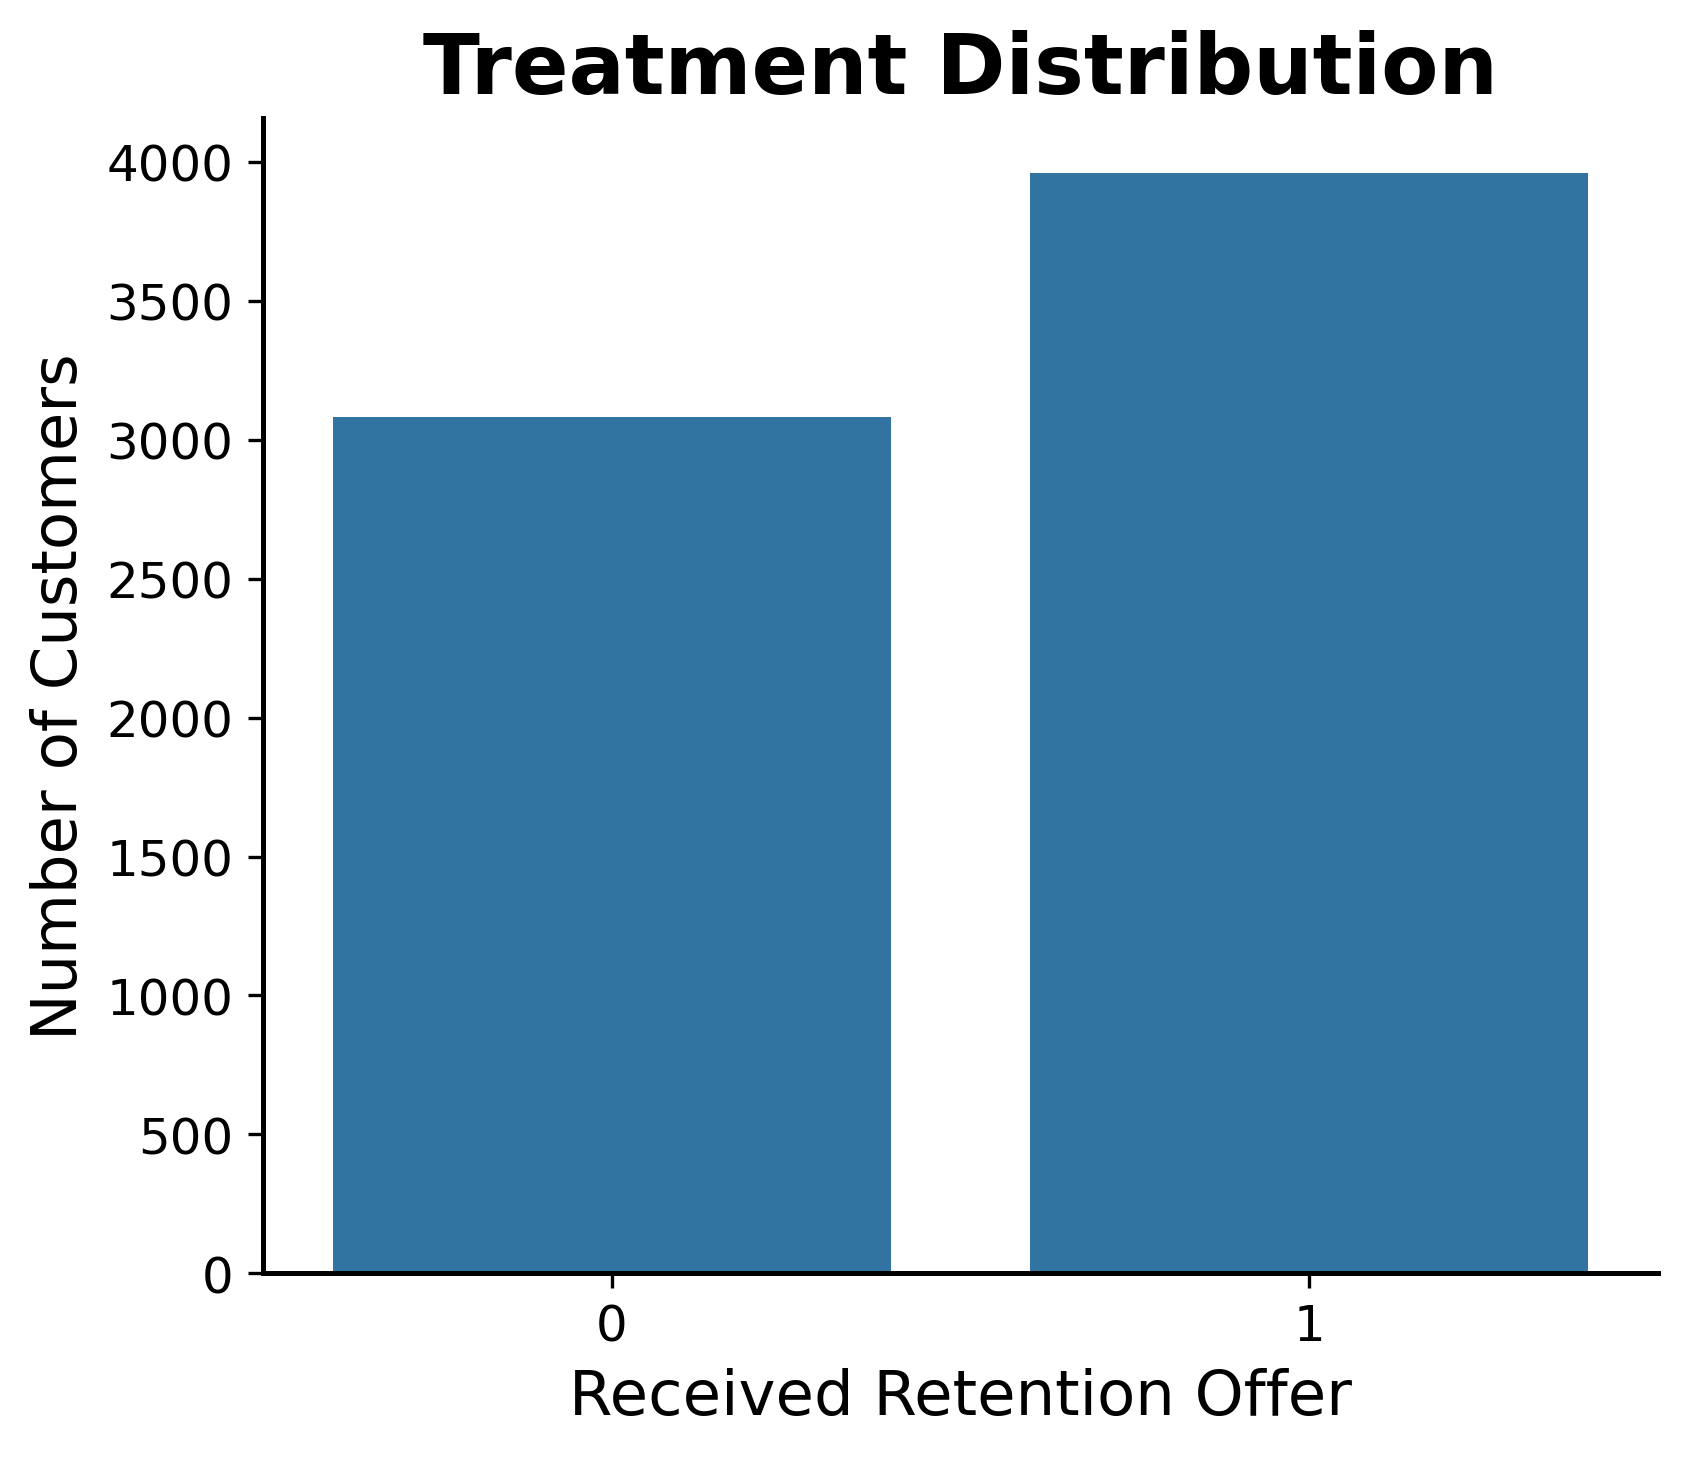

In [117]:
offer_counts = (
    df[TREATMENT]
    .value_counts()
    .reset_index()
)

offer_counts.columns = ["Received Offer", "Customers"]

display(offer_counts)

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x=TREATMENT
)

plt.title("Treatment Distribution")
plt.xlabel("Received Retention Offer")
plt.ylabel("Number of Customers")

plt.show()

,Received Offer,Churn Rate
0,0,0.160882
1,1,0.271970


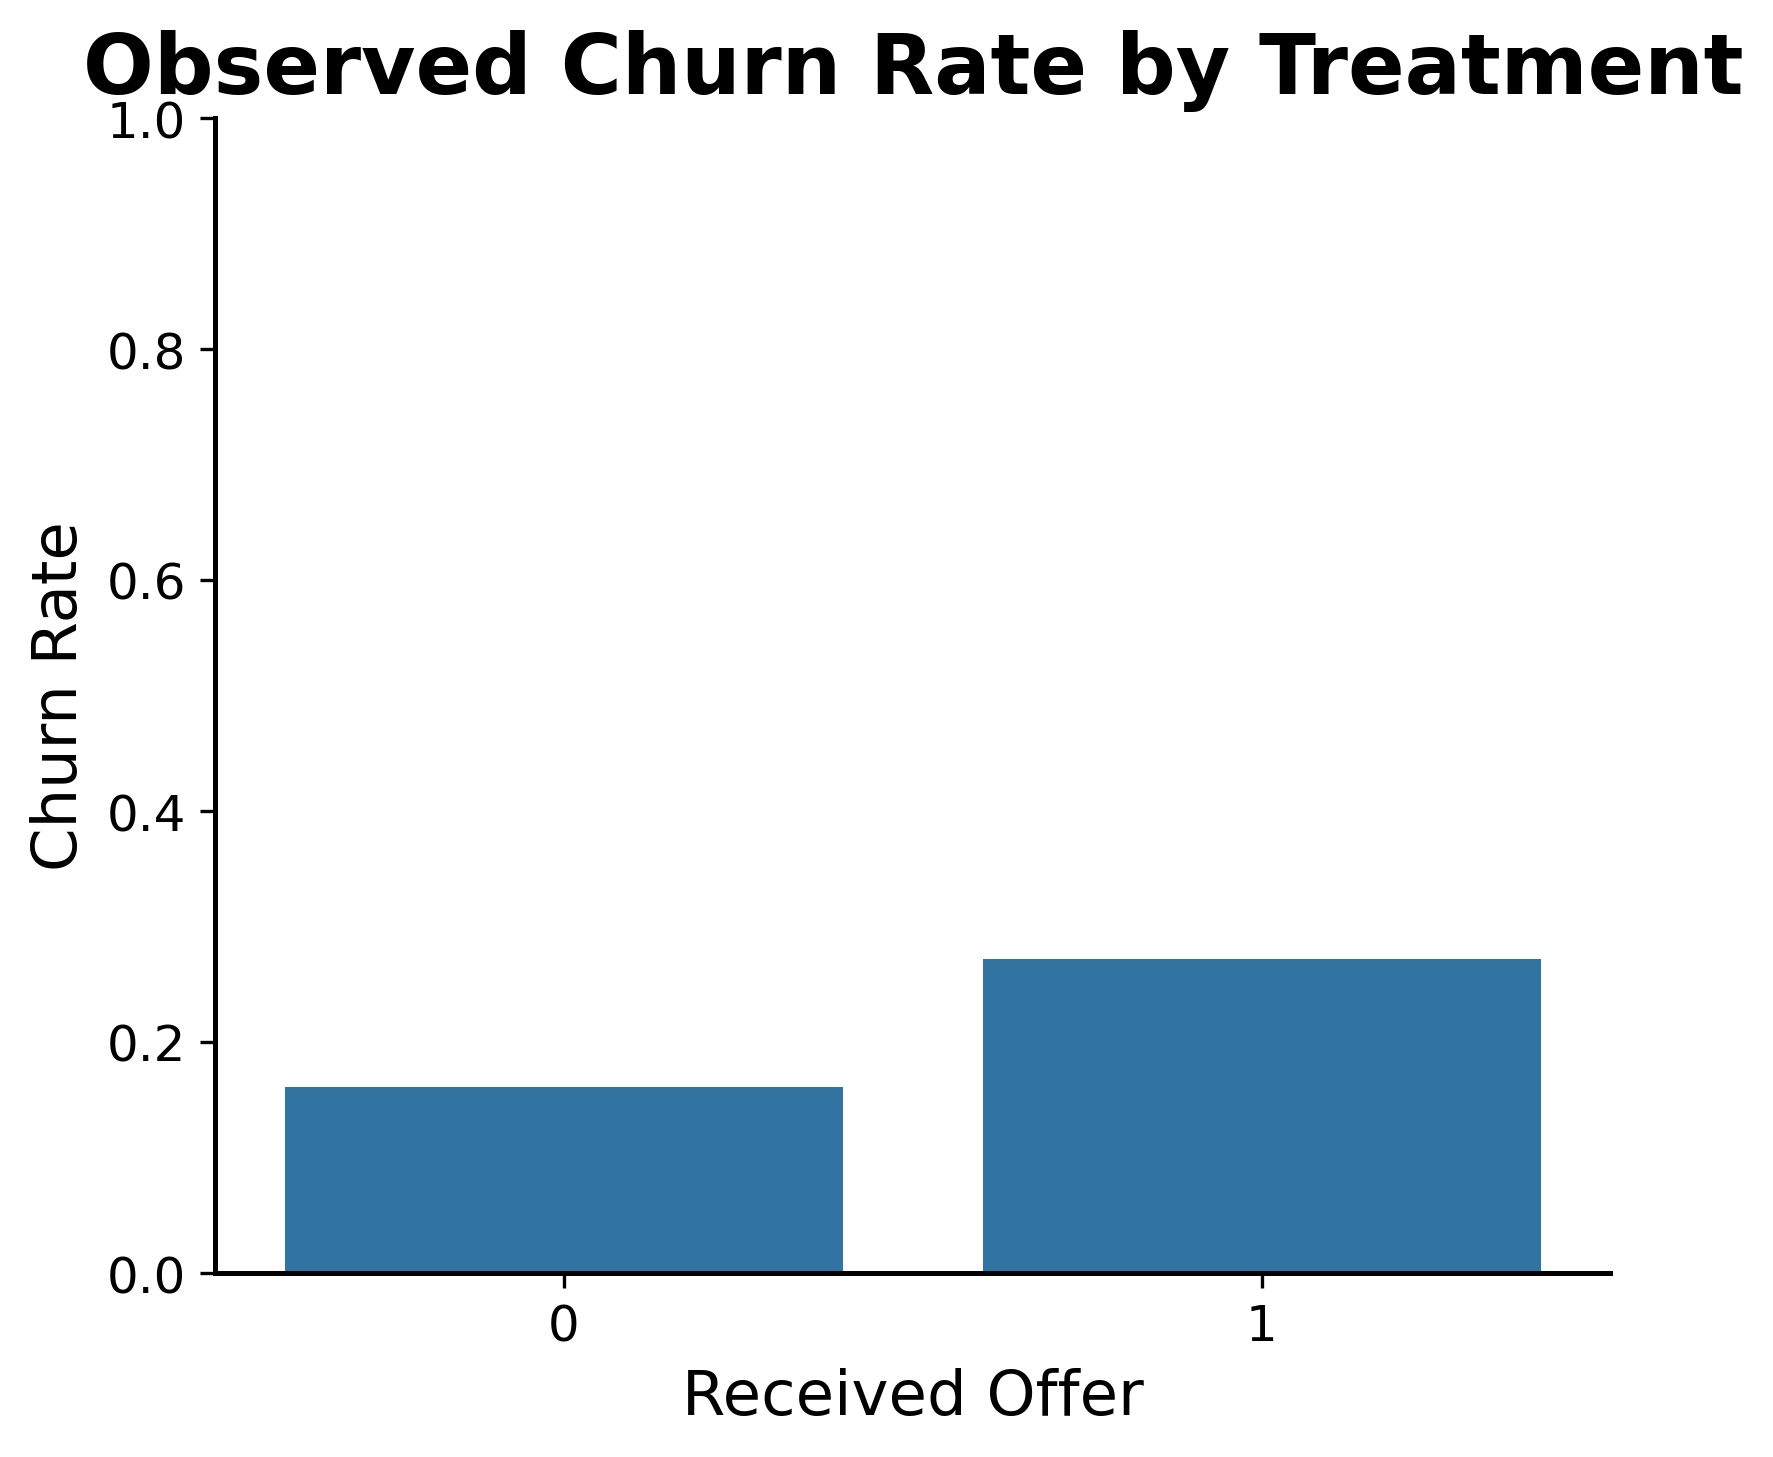

In [118]:
summary = (
    df
    .groupby(TREATMENT)[OUTCOME]
    .mean()
    .reset_index()
)

summary.columns = [
    "Received Offer",
    "Churn Rate"
]

display(summary)

plt.figure(figsize=(6,5))

sns.barplot(
    data=summary,
    x="Received Offer",
    y="Churn Rate"
)

plt.ylim(0,1)

plt.title("Observed Churn Rate by Treatment")

plt.ylabel("Churn Rate")

plt.show()

,Contract,Customers
0,Month-to-month,3875
1,Two year,1695
2,One year,1473


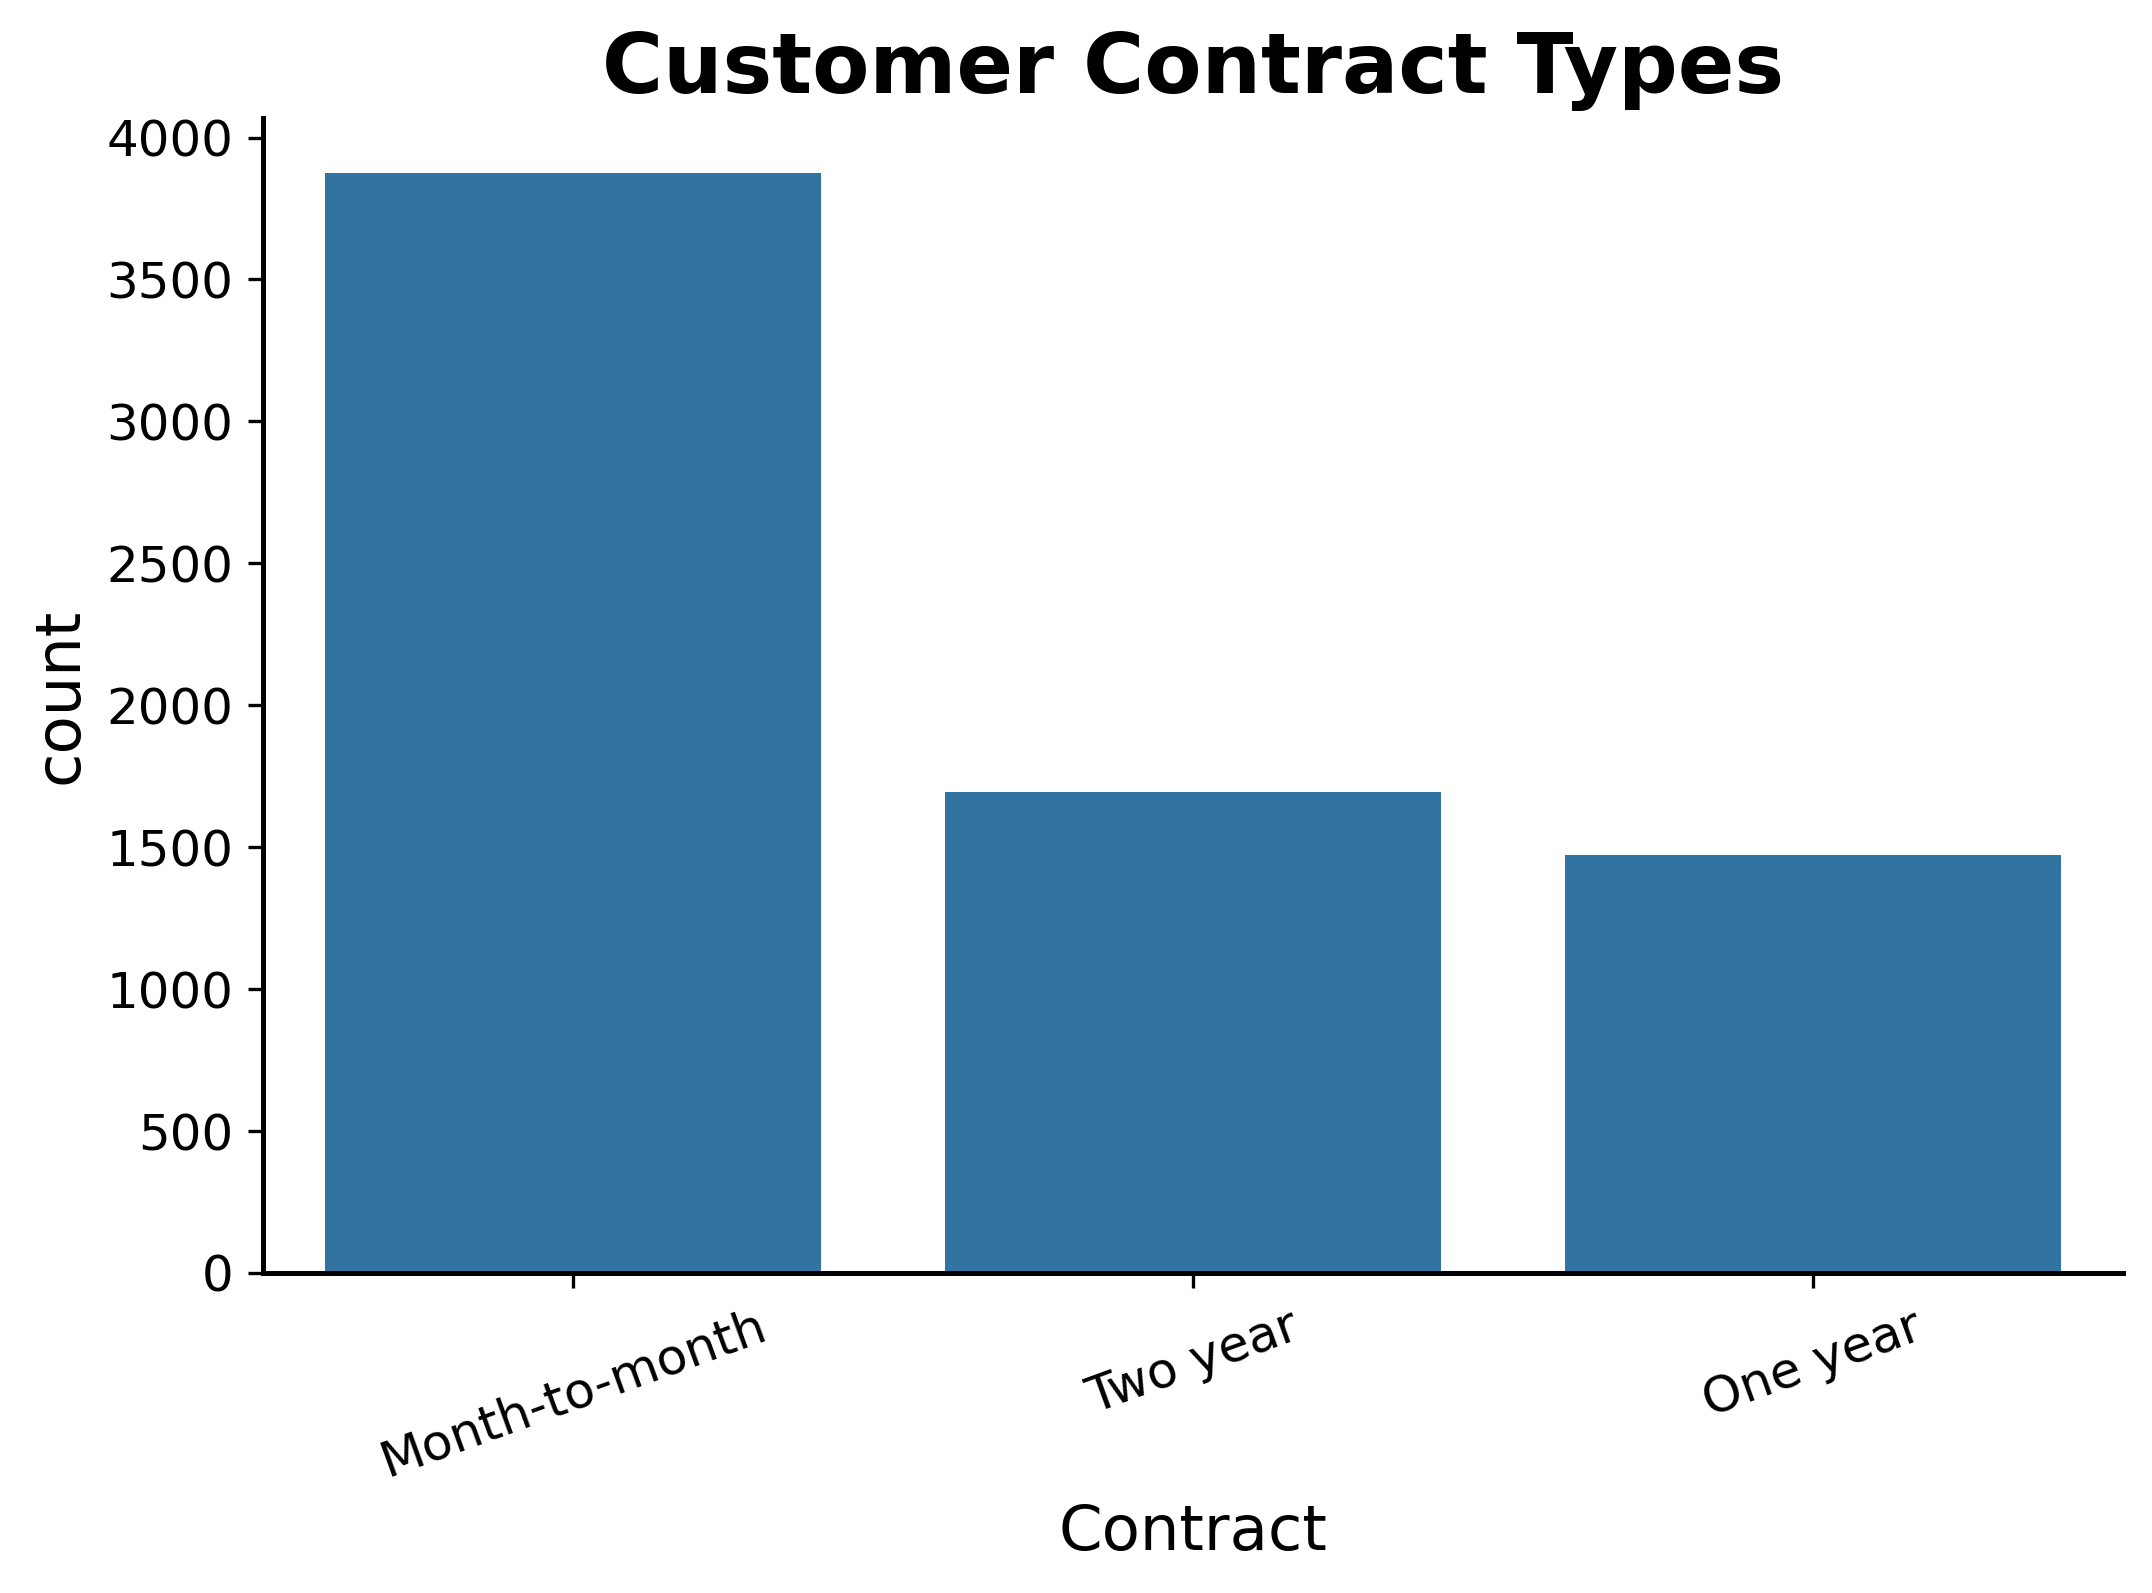

In [119]:
contract = (
    df["Contract"]
    .value_counts()
    .reset_index()
)

contract.columns = [
    "Contract",
    "Customers"
]

display(contract)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    order=df["Contract"].value_counts().index
)

plt.title("Customer Contract Types")

plt.xticks(rotation=20)

plt.show()

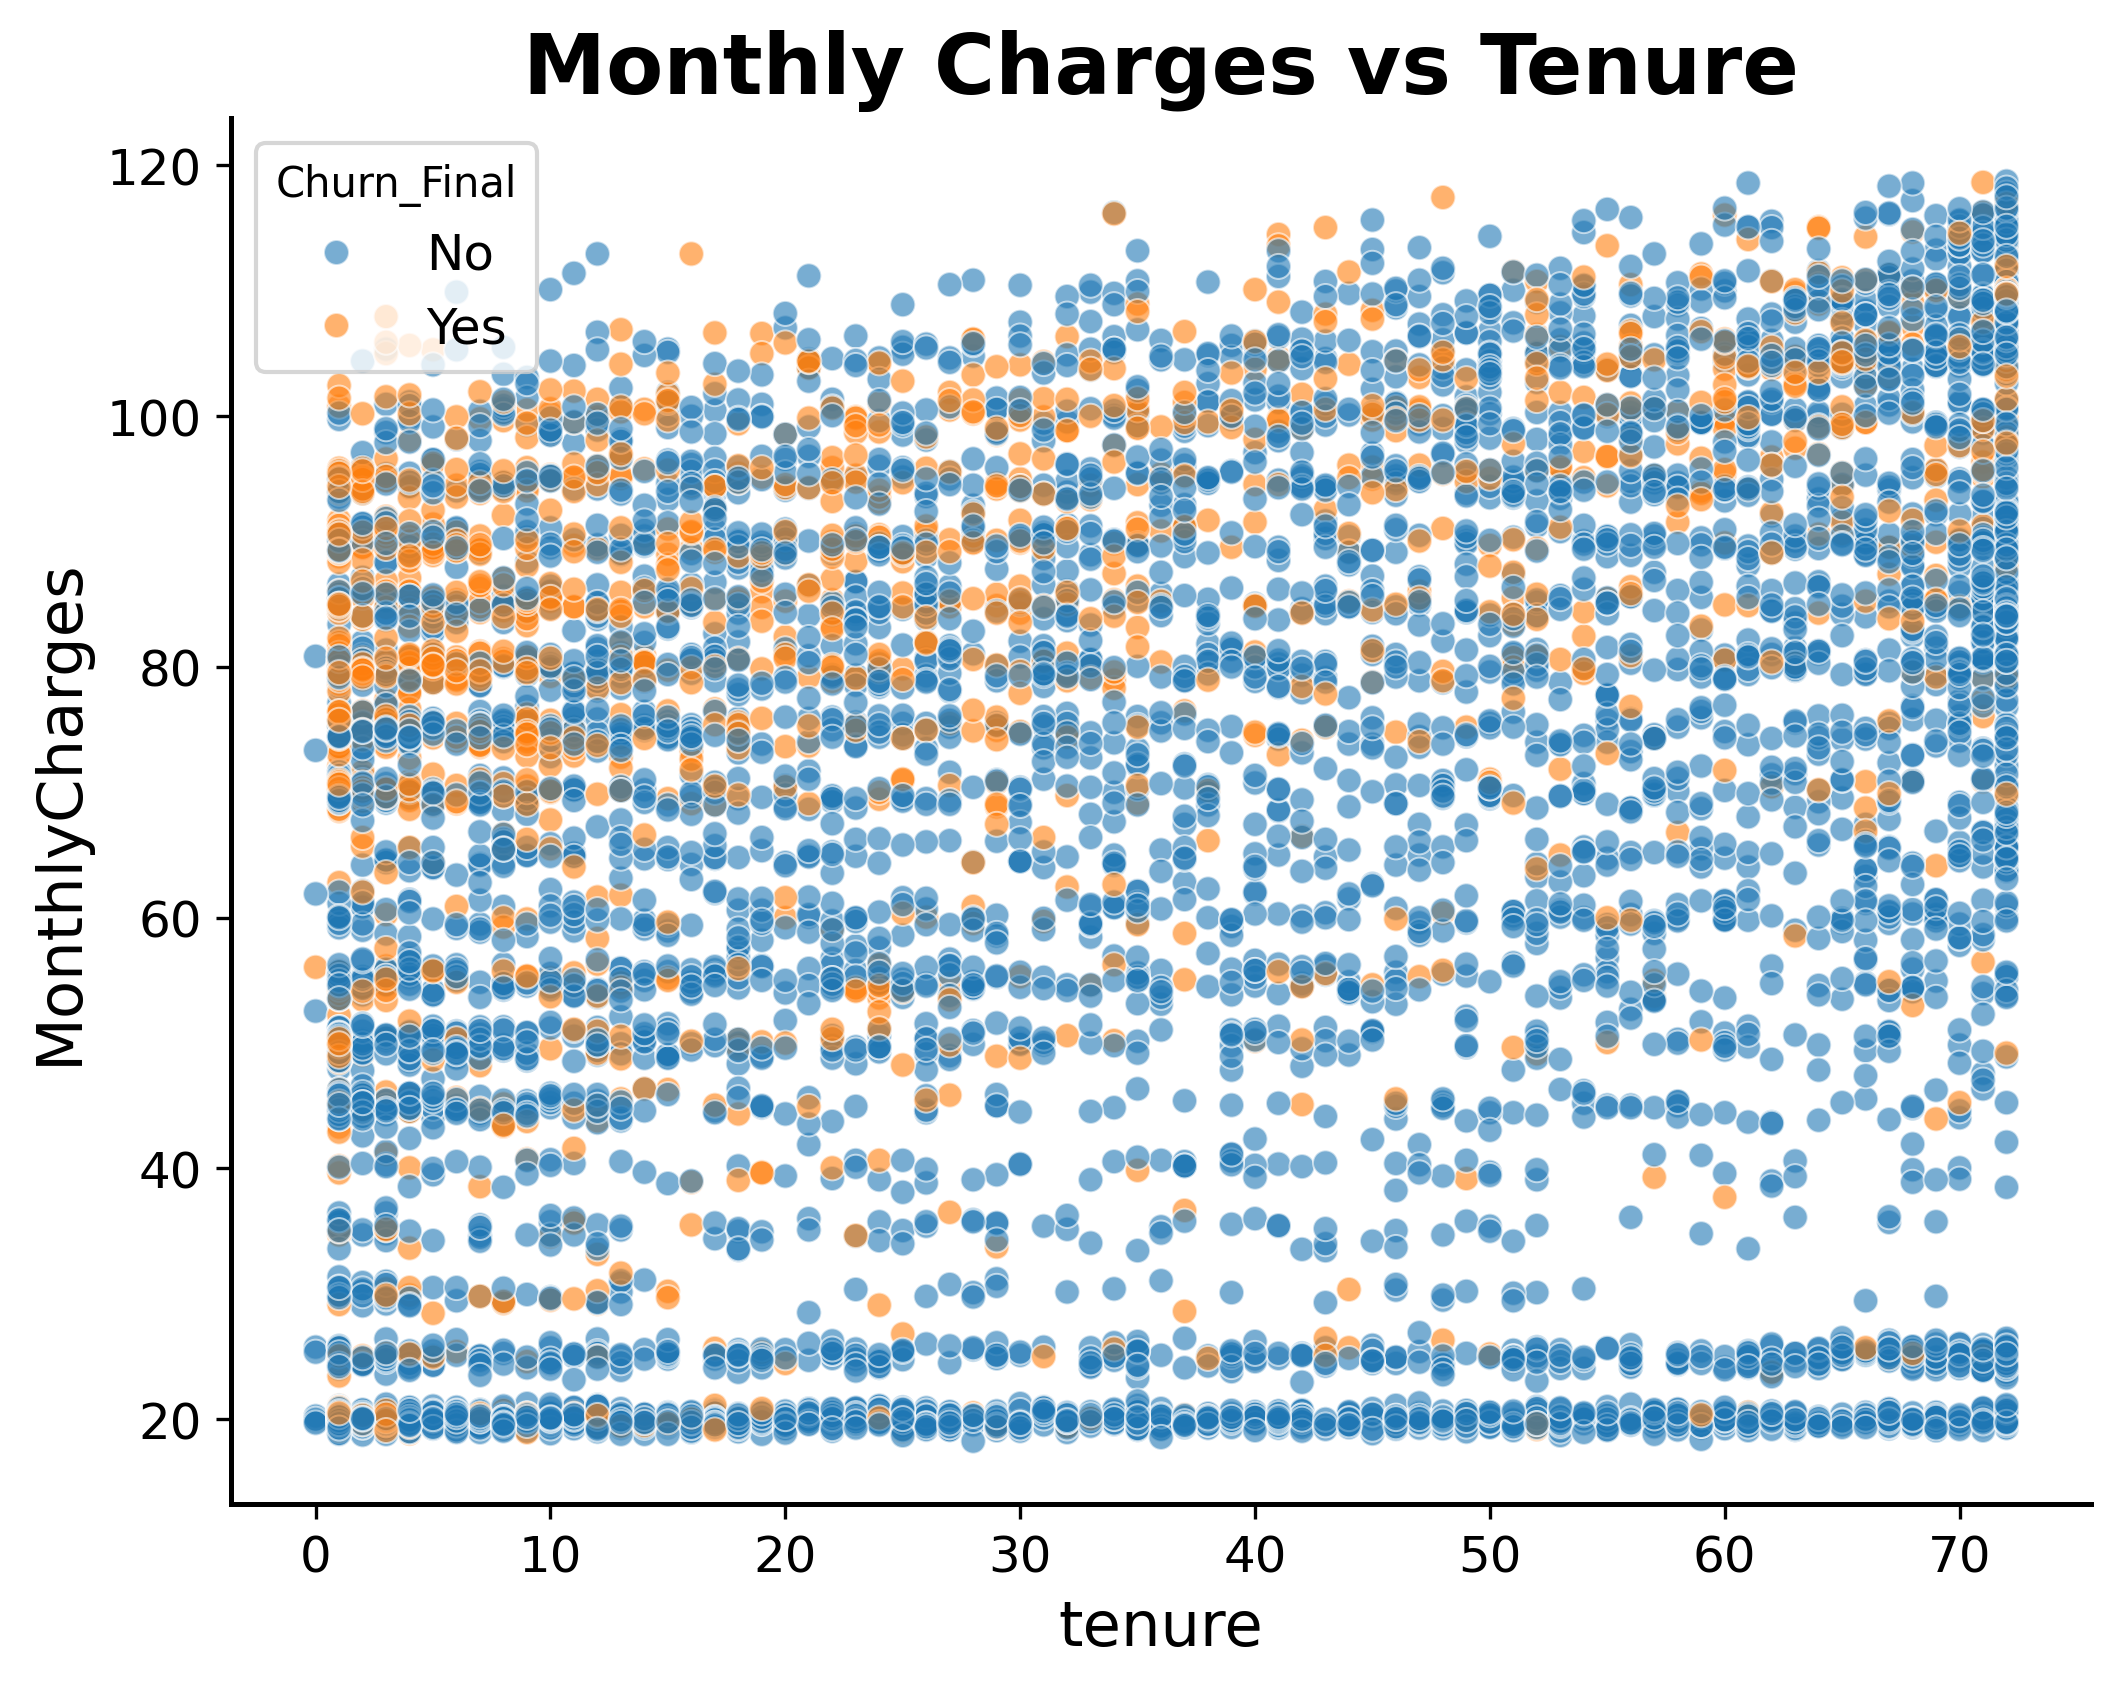

In [120]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn_Final",
    alpha=0.6
)

plt.title("Monthly Charges vs Tenure")

plt.show()

In [121]:
business_summary = pd.DataFrame({

    "Metric":[

        "Customers",

        "Offer Rate",

        "Observed Churn Rate",

        "Average Monthly Charges",

        "Average Customer Value",

        "Average Offer Cost"

    ],

    "Value":[

        len(df),

        round(df[TREATMENT].mean(),3),

        round(df[OUTCOME].mean(),3),

        round(df["MonthlyCharges"].mean(),2),

        round(df["Customer_Value"].mean(),2),

        round(df["Offer_Cost"].mean(),2)

    ]

})

display(business_summary)

,Metric,Value
0,Customers,7043.000
1,Offer Rate,0.562
2,Observed Churn Rate,0.223
3,Average Monthly Charges,64.760
4,Average Customer Value,508.160
5,Average Offer Cost,5.620


# 3. Overall Causal Analysis

The primary objective of this section is to estimate the overall causal effect of the retention campaign on customer churn.

Since customers are not randomly assigned to receive retention offers, a simple comparison between treated and untreated customers is biased. Multiple causal inference methods are therefore employed to adjust for selection bias and confounding.

The following methods are implemented:

- Naïve Difference
- Propensity Score Estimation
- Propensity Score Matching (PSM)
- Inverse Probability Weighting (IPW)
- Doubly Robust Estimation (DR)

In [122]:
causal_df = df.copy()

causal_df = causal_df.dropna(
    subset=[TREATMENT, OUTCOME]
).copy()

causal_df[TREATMENT] = causal_df[TREATMENT].astype(int)
causal_df[OUTCOME] = causal_df[OUTCOME].astype(int)

print(causal_df.shape)

(7043, 46)


In [123]:
X = causal_df[BASELINE_COLS].copy()

numeric_cols = [
    c for c in BASELINE_COLS
    if pd.api.types.is_numeric_dtype(X[c])
]

categorical_cols = [
    c for c in BASELINE_COLS
    if c not in numeric_cols
]

for c in numeric_cols:
    X[c] = pd.to_numeric(
        X[c],
        errors="coerce"
    )

    X[c] = X[c].fillna(
        X[c].median()
    )

for c in categorical_cols:
    X[c] = (
        X[c]
        .fillna("Missing")
        .astype(str)
    )

X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(7043, 30)


In [124]:
T = causal_df[TREATMENT].values

Y = causal_df[OUTCOME].values

## 3.1 Naïve Campaign Evaluation

The naïve estimate compares the observed churn rates of customers who received an offer against those who did not. Since treatment assignment is not random, this estimate does not account for confounding variables and therefore should not be interpreted as a causal effect.


In [125]:
treated_rate = causal_df.loc[
    causal_df[TREATMENT] == 1,
    OUTCOME
].mean()

control_rate = causal_df.loc[
    causal_df[TREATMENT] == 0,
    OUTCOME
].mean()

naive_effect = treated_rate - control_rate

naive_results = pd.DataFrame({

    "Metric":[
        "Treatment Churn Rate",
        "Control Churn Rate",
        "Naive Difference"
    ],

    "Value":[
        treated_rate,
        control_rate,
        naive_effect
    ]

})

display(
    naive_results.round(4)
)

,Metric,Value
0,Treatment Churn Rate,0.2720
1,Control Churn Rate,0.1609
2,Naive Difference,0.1111


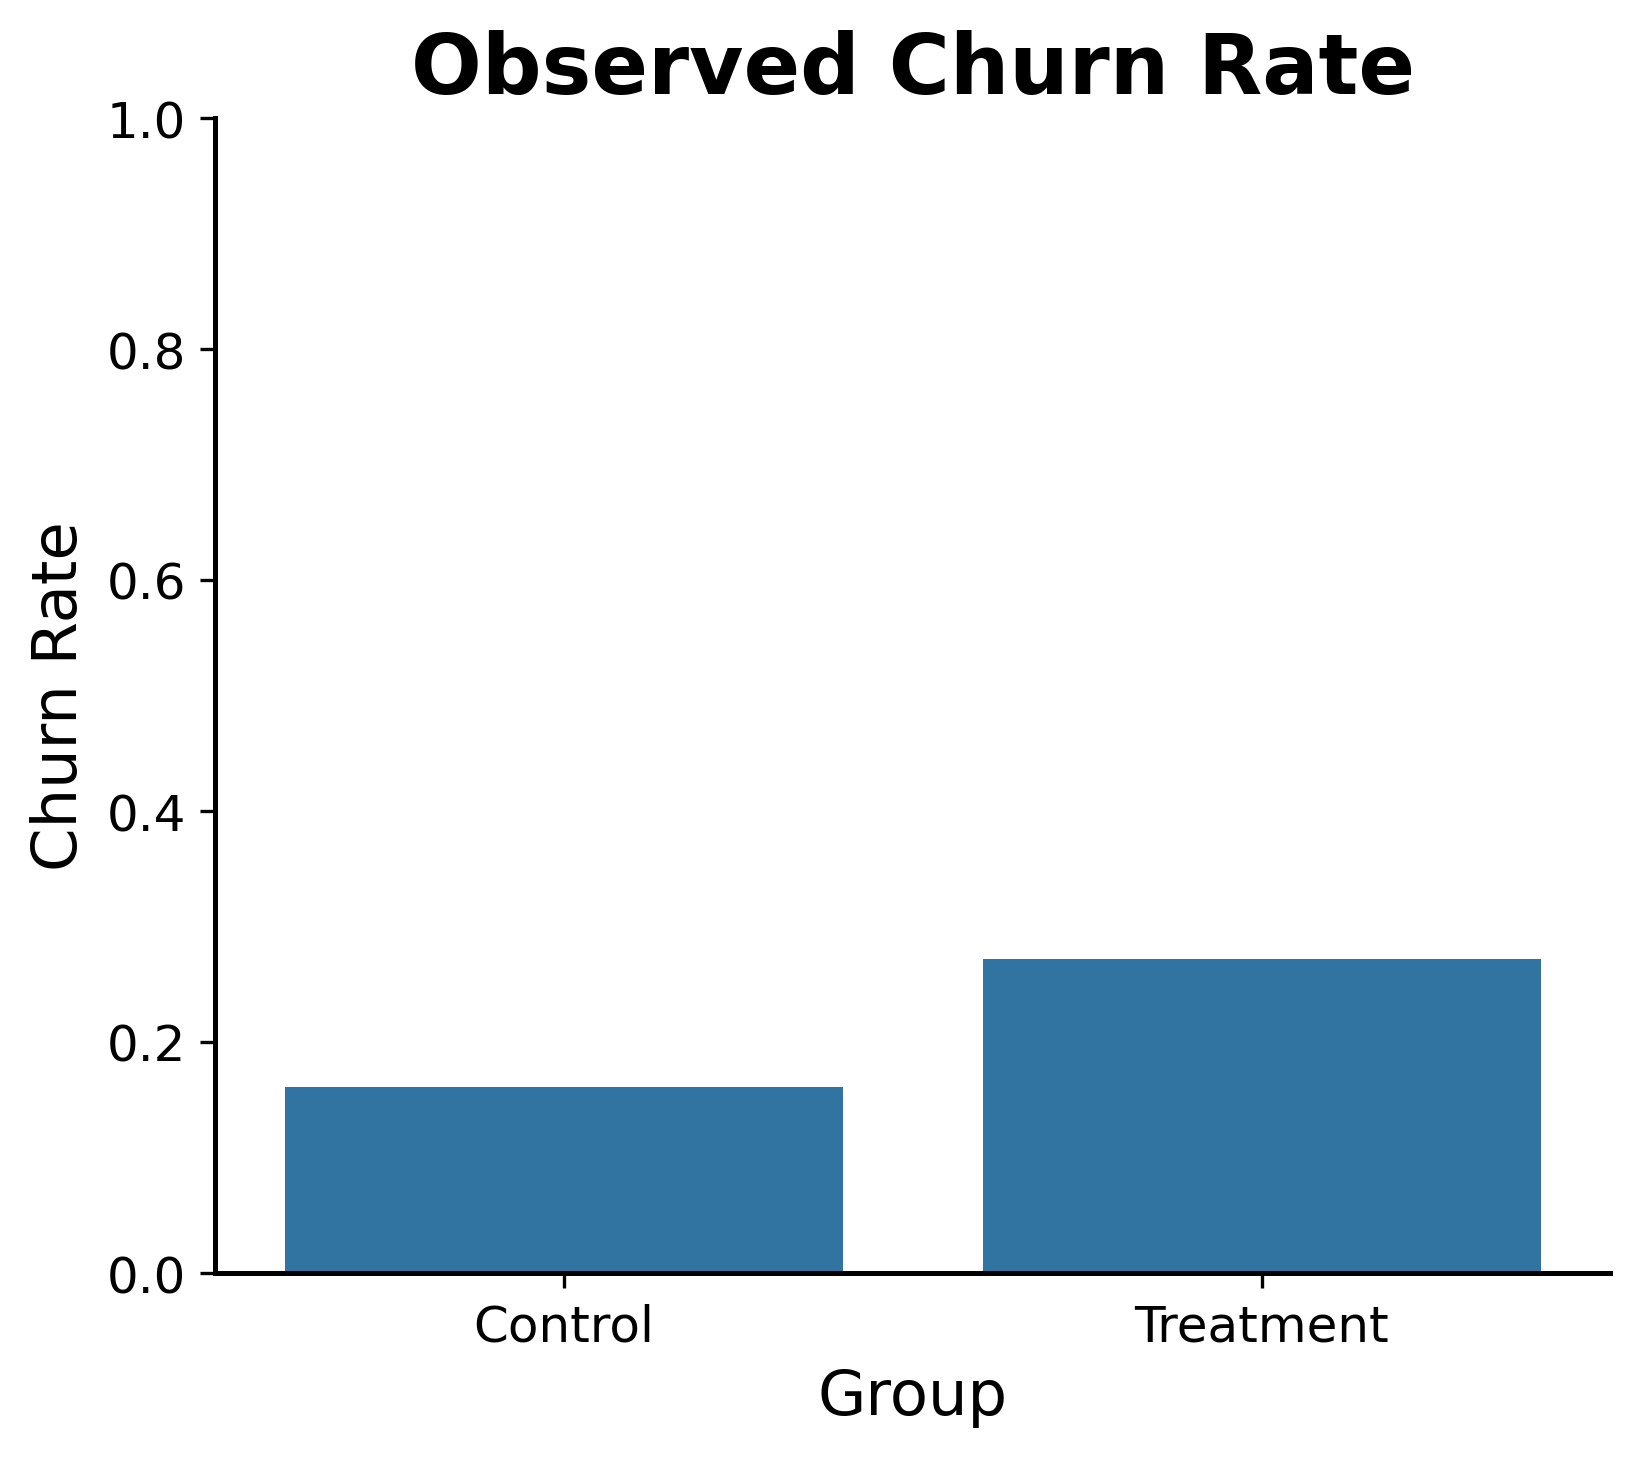

In [126]:
comparison = pd.DataFrame({

    "Group":[
        "Control",
        "Treatment"
    ],

    "Churn Rate":[
        control_rate,
        treated_rate
    ]

})

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Group",
    y="Churn Rate"
)

plt.ylim(0,1)

plt.title("Observed Churn Rate")

plt.show()

## 3.2 Propensity Score Estimation

Propensity scores estimate the probability of receiving a retention offer given a customer's observed characteristics.

These scores are later used for matching and weighting methods to reduce confounding bias.

In [127]:
ps_model = LogisticRegression(

    max_iter=1000,

    random_state=42

)

ps_model.fit(
    X,
    T
)

propensity = ps_model.predict_proba(X)[:,1]

propensity = np.clip(
    propensity,
    0.01,
    0.99
)

causal_df["Estimated_Propensity"] = propensity

In [128]:
display(
    causal_df["Estimated_Propensity"]
    .describe()
)

,Estimated_Propensity
count,7043.000000
mean,0.562334
std,0.277149
min,0.089044
25%,0.256392
50%,0.592362
75%,0.834226
max,0.960650


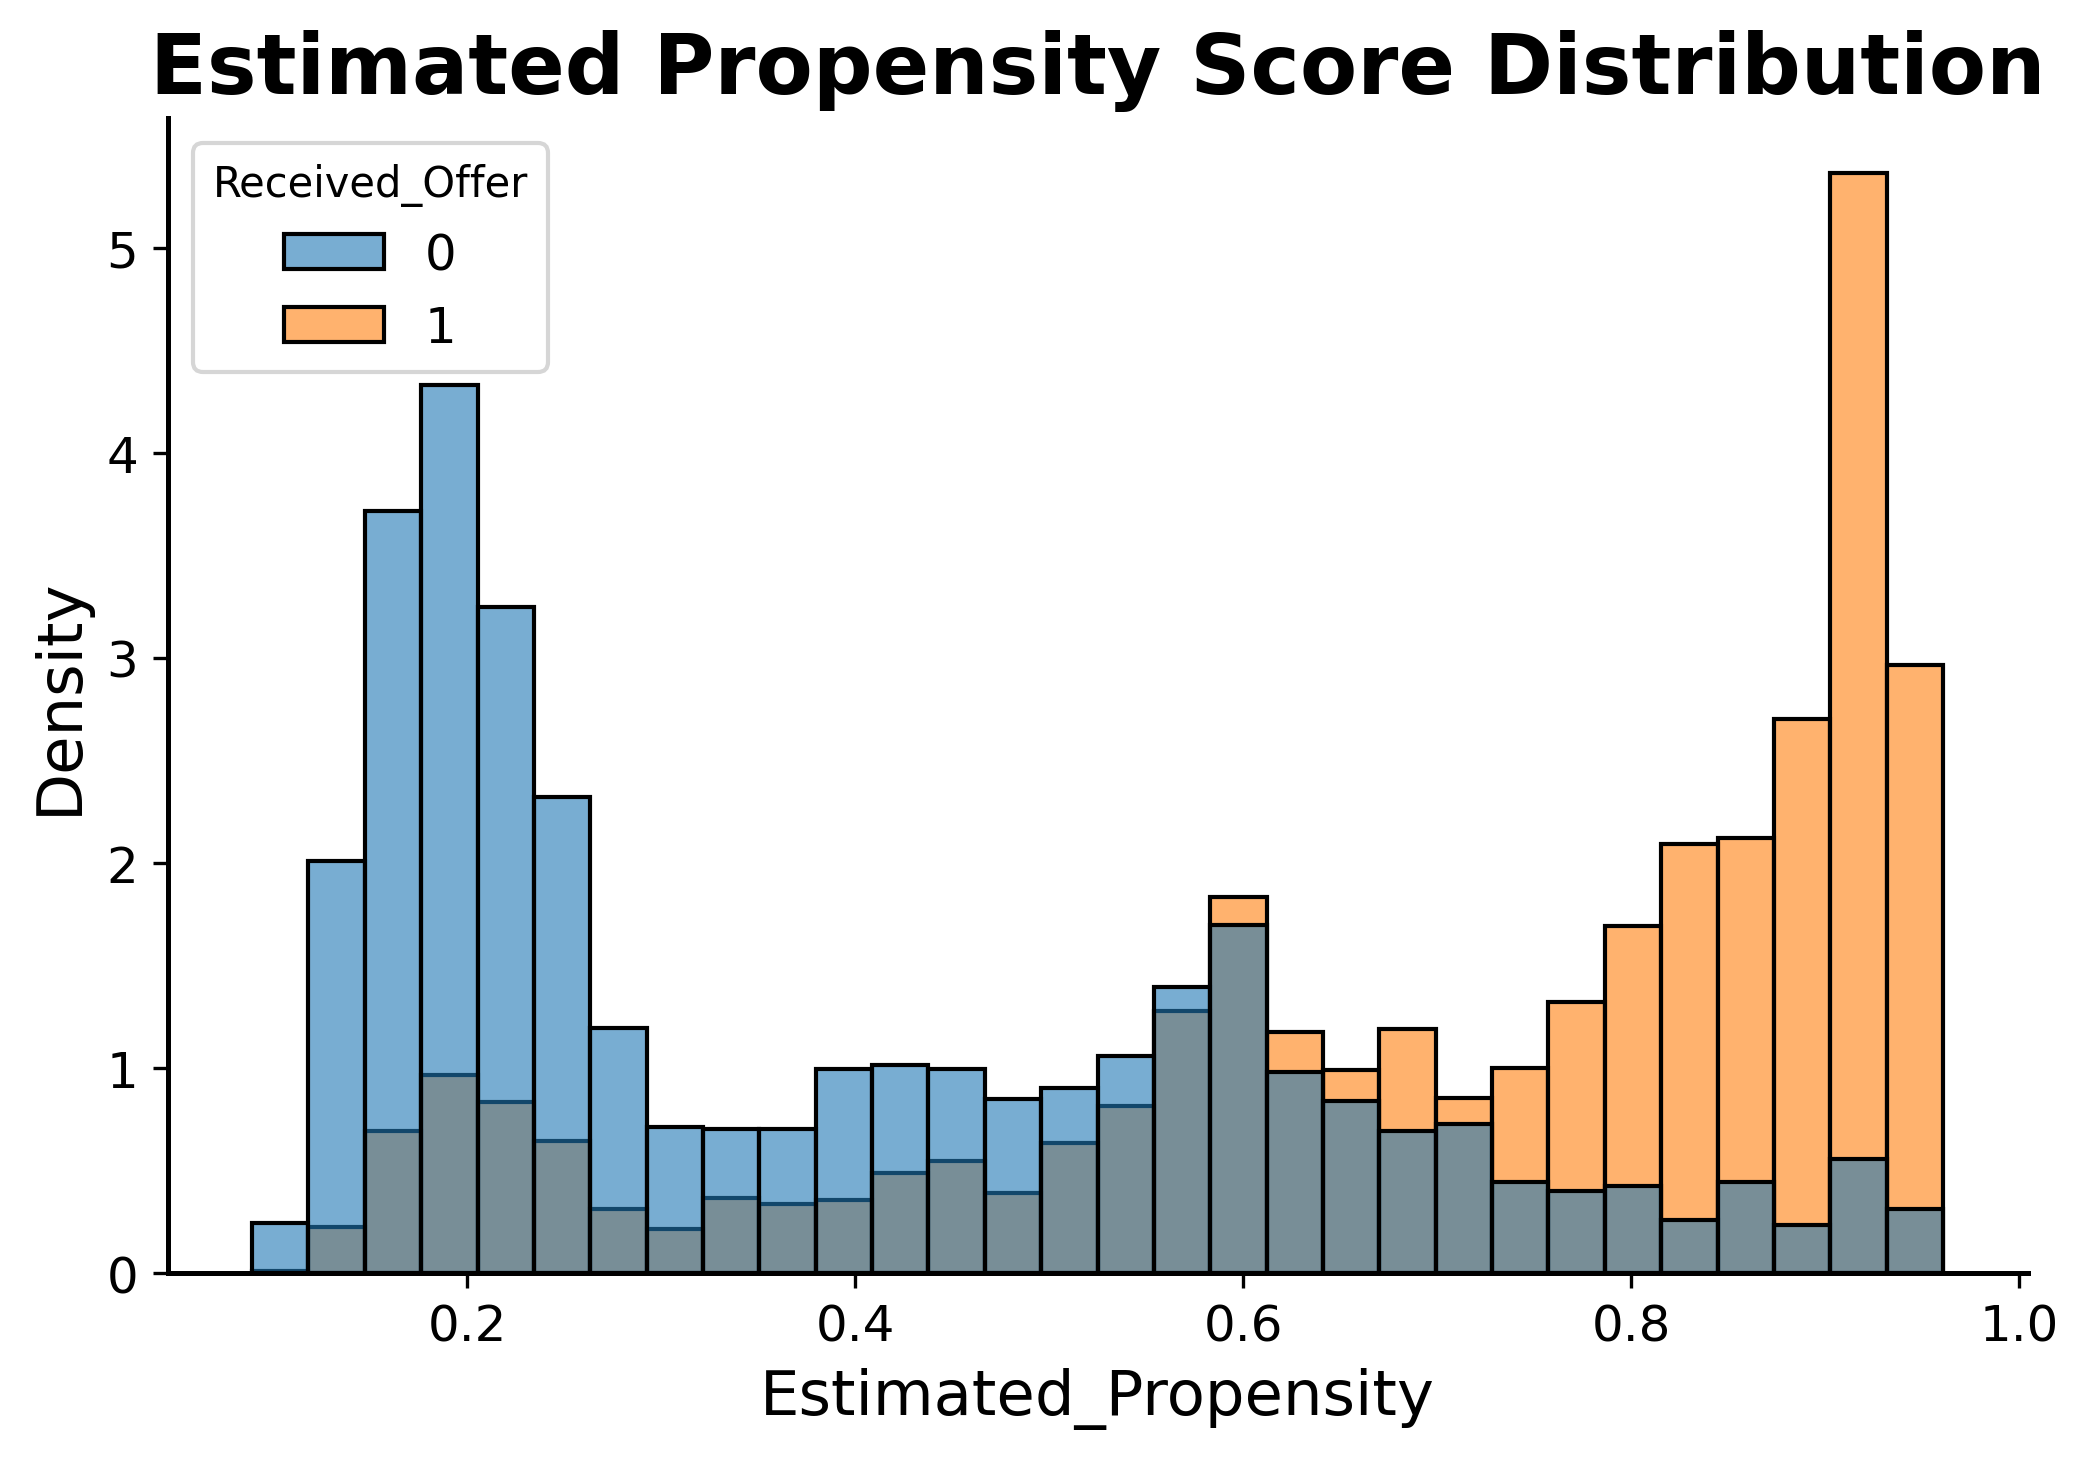

In [129]:
plt.figure(figsize=(8,5))

sns.histplot(

    data=causal_df,

    x="Estimated_Propensity",

    hue=TREATMENT,

    bins=30,

    stat="density",

    common_norm=False,

    alpha=0.6

)

plt.title("Estimated Propensity Score Distribution")

plt.show()

## 3.3 Propensity Score Matching

Propensity Score Matching pairs treated customers with similar untreated customers based on their estimated propensity scores. This estimates the Average Treatment Effect on the Treated (ATT).

In [130]:
treated_idx = np.where(T==1)[0]

control_idx = np.where(T==0)[0]

treated_ps = propensity[
    treated_idx
].reshape(-1,1)

control_ps = propensity[
    control_idx
].reshape(-1,1)

nn = NearestNeighbors(
    n_neighbors=1
)

nn.fit(control_ps)

_, matched = nn.kneighbors(
    treated_ps
)

matched_control = control_idx[
    matched.flatten()
]

psm_effect = np.mean(

    Y[treated_idx]

    -

    Y[matched_control]

)

print(f"PSM ATT : {psm_effect:.4f}")

PSM ATT : -0.1482


## 3.4 Inverse Probability Weighting

Inverse Probability Weighting creates a weighted pseudo-population in which treatment assignment becomes independent of observed confounders.

In [131]:
weights = np.where(T==1,
                   1/propensity,
                   1/(1-propensity)
                   )
ipw_effect = (np.sum(weights*T*Y) / np.sum(weights*T)) - (np.sum(weights*(1-T)*Y) / np.sum(weights*(1-T)))

print(f"IPW ATE : {ipw_effect:.4f}")

IPW ATE : -0.1011


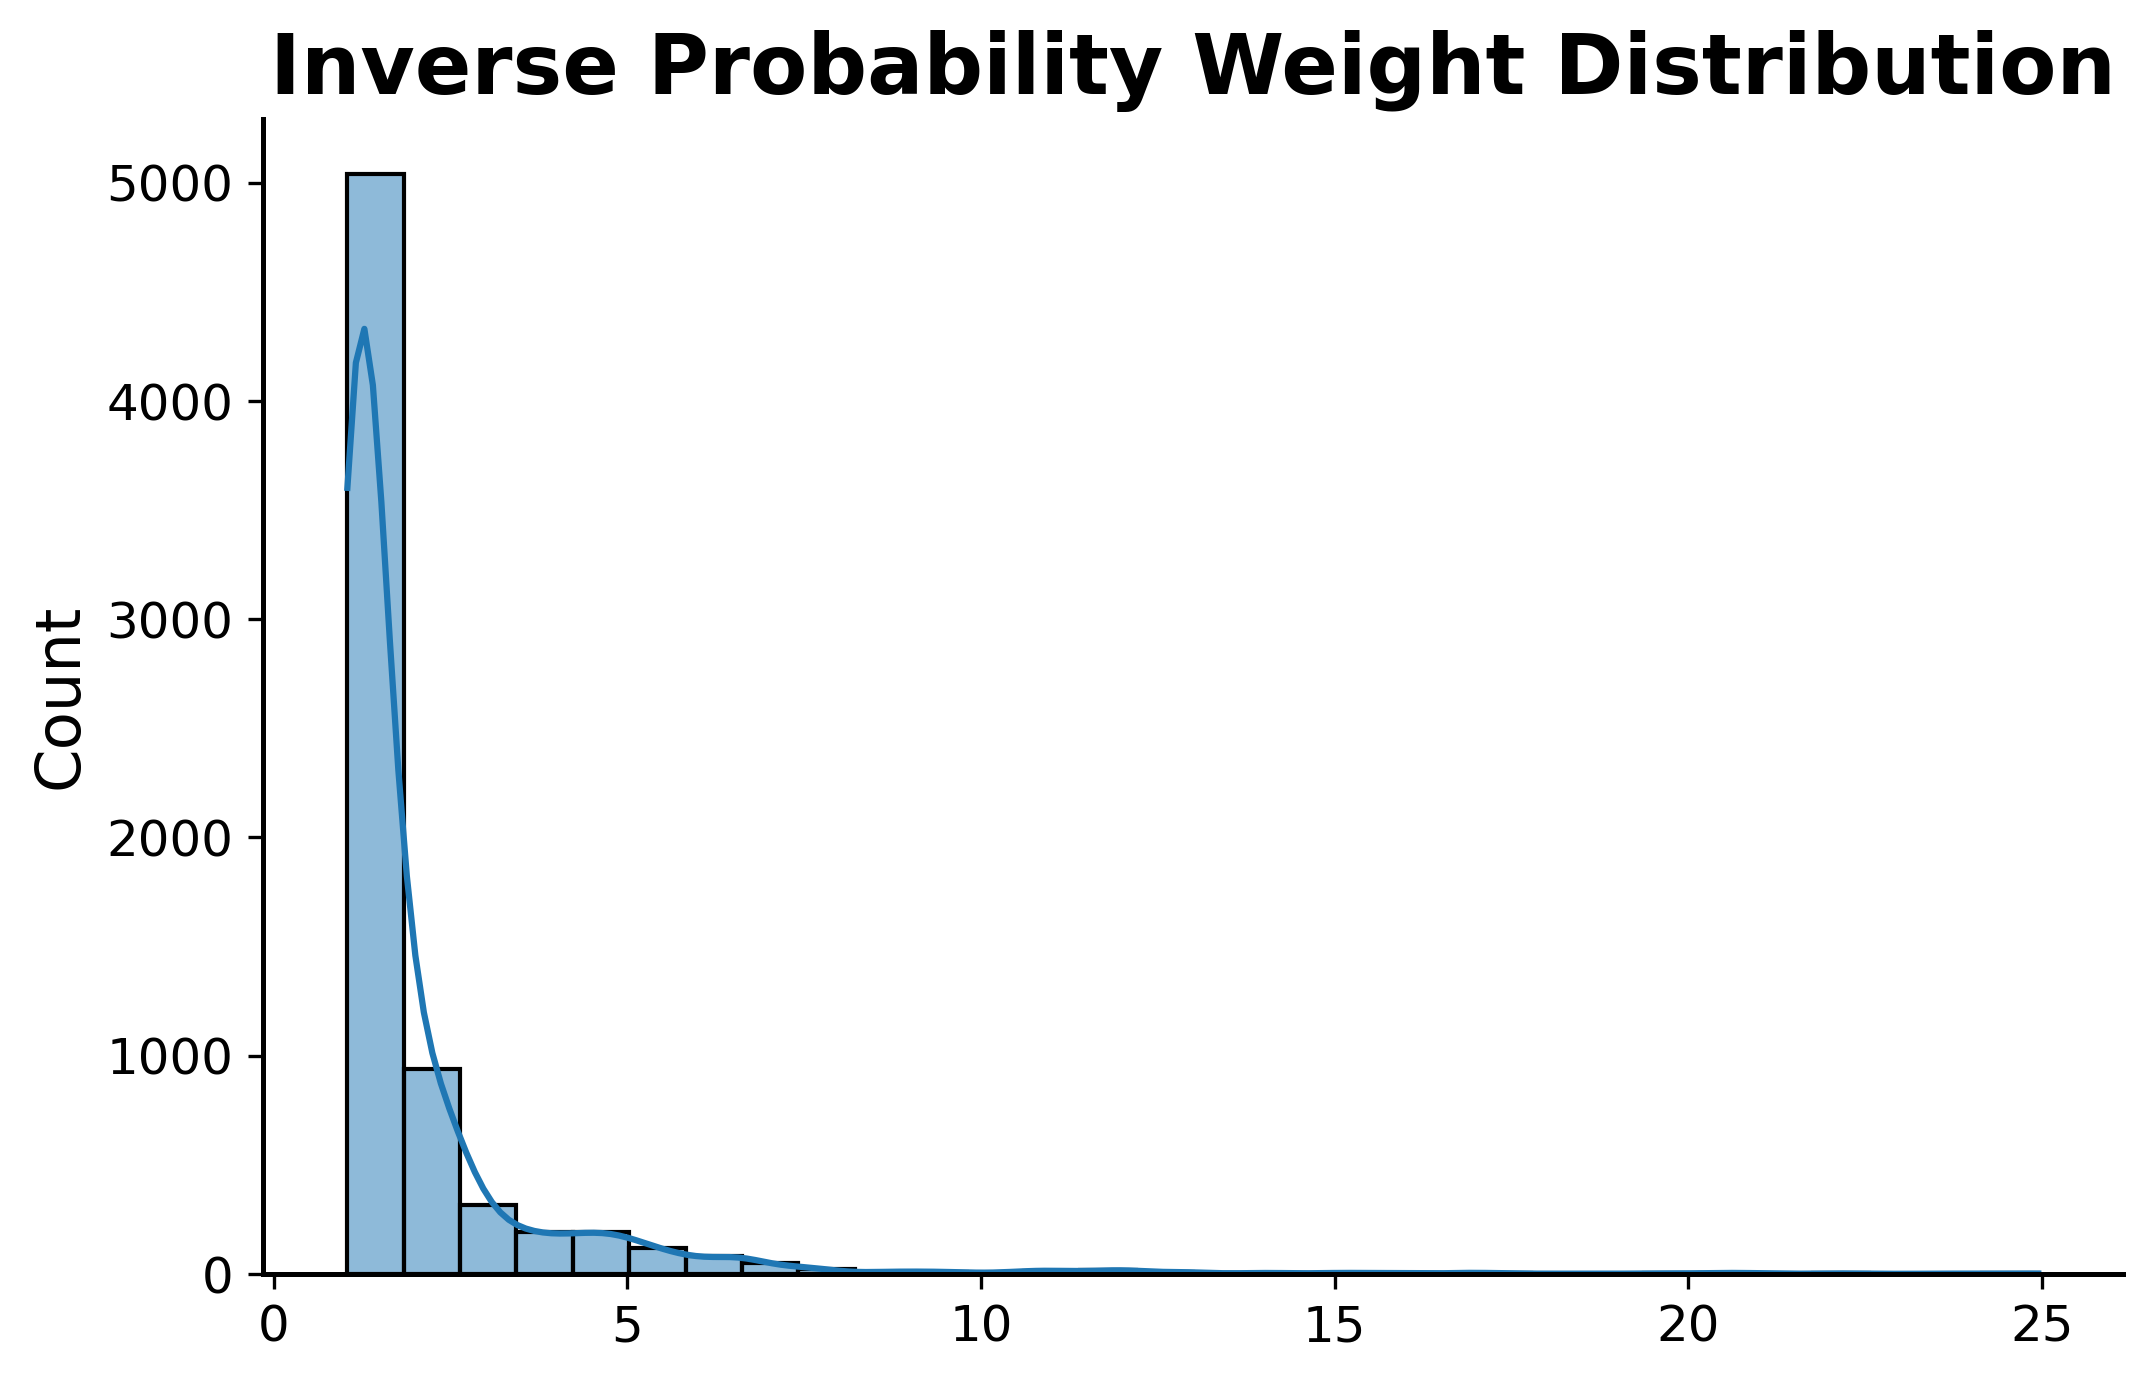

In [132]:
plt.figure(figsize=(8,5))

sns.histplot(

    weights,

    bins=30,

    kde=True

)

plt.title("Inverse Probability Weight Distribution")

plt.show()

## 3.5 Doubly Robust Estimation

Doubly Robust estimation combines outcome regression and propensity score weighting. The estimator remains consistent if either the propensity model or the outcome model is correctly specified.

In [133]:
rf_treated = RandomForestRegressor(

    n_estimators=200,

    random_state=42

)

rf_control = RandomForestRegressor(

    n_estimators=200,

    random_state=42

)

rf_treated.fit(

    X[T==1],

    Y[T==1]

)

rf_control.fit(

    X[T==0],

    Y[T==0]

)

RandomForestRegressor(n_estimators=200, random_state=42)

In [134]:
mu1 = rf_treated.predict(X)

mu0 = rf_control.predict(X)

dr_scores = (

    mu1

    -

    mu0

    +

    T*(Y-mu1)/propensity

    -

    (1-T)*(Y-mu0)/(1-propensity)

)

dr_effect = dr_scores.mean()

print(f"Doubly Robust ATE : {dr_effect:.4f}")

Doubly Robust ATE : -0.0899


In [135]:
overall_methods = pd.DataFrame({

    "Method":[

        "Naive",

        "PSM",

        "IPW",

        "Doubly Robust"

    ],

    "Estimated Effect":[

        naive_effect,

        psm_effect,

        ipw_effect,

        dr_effect

    ]

})

display(
    overall_methods.round(4)
)

,Method,Estimated Effect
0,Naive,0.1111
1,PSM,-0.1482
2,IPW,-0.1011
3,Doubly Robust,-0.0899


## 3.6 DoWhy Causal Analysis

To further validate the estimated treatment effect, a structural causal model is constructed using the DoWhy framework.

DoWhy explicitly models the assumed causal relationships between treatment, outcome, and observed confounders before estimating the Average Treatment Effect (ATE). The robustness of the estimate is then evaluated using multiple refutation tests.

In [136]:
dowhy_df = causal_df.copy()

confounders = X.columns.tolist()

dowhy_df = pd.concat(

    [

        dowhy_df[[TREATMENT, OUTCOME]].reset_index(drop=True),

        X.reset_index(drop=True)

    ],

    axis=1

)

print(dowhy_df.shape)

print(f"Number of Confounders : {len(confounders)}")

(7043, 32)
Number of Confounders : 30


In [137]:
model = CausalModel(

    data=dowhy_df,

    treatment=TREATMENT,

    outcome=OUTCOME,

    common_causes=confounders

)

In [138]:
identified_estimand = model.identify_effect(

    proceed_when_unidentifiable=True

)
estimate = model.estimate_effect(

    identified_estimand,

    method_name="backdoor.linear_regression"

)

In [139]:
dowhy_effect = estimate.value

print(f"Estimated ATE : {dowhy_effect:.4f}")

Estimated ATE : -0.0826


### Robustness Checks

To evaluate the stability of the estimated causal effect, three refutation tests are performed:

- Random Common Cause Refuter
- Placebo Treatment Refuter
- Data Subset Refuter

If the estimated treatment effect remains relatively stable, confidence in the causal estimate increases.

In [140]:
random_refuter = model.refute_estimate(

    identified_estimand,

    estimate,

    method_name="random_common_cause"

)

In [141]:
placebo_refuter = model.refute_estimate(

    identified_estimand,

    estimate,

    method_name="placebo_treatment_refuter"

)

In [142]:
subset_refuter = model.refute_estimate(

    identified_estimand,

    estimate,

    method_name="data_subset_refuter"

)

In [143]:
refutation_summary = pd.DataFrame({

    "Refuter":[

        "Random Common Cause",

        "Placebo Treatment",

        "Data Subset"

    ],

    "Estimated Effect":[

        getattr(random_refuter, "new_effect", np.nan),

        getattr(placebo_refuter, "new_effect", np.nan),

        getattr(subset_refuter, "new_effect", np.nan)

    ]

})

display(refutation_summary.round(4))

,Refuter,Estimated Effect
0,Random Common Cause,-0.0826
1,Placebo Treatment,0.0012
2,Data Subset,-0.0829


## 3.7 Comparison of Causal Estimators

The treatment effect estimated using different causal inference techniques is compared to evaluate consistency across methods.

Agreement among multiple estimators provides greater confidence in the robustness of the findings.

In [144]:
comparison = overall_methods.copy()

comparison.loc[len(comparison)] = [

    "DoWhy",

    dowhy_effect

]

display(comparison.round(4))

,Method,Estimated Effect
0,Naive,0.1111
1,PSM,-0.1482
2,IPW,-0.1011
3,Doubly Robust,-0.0899
4,DoWhy,-0.0826


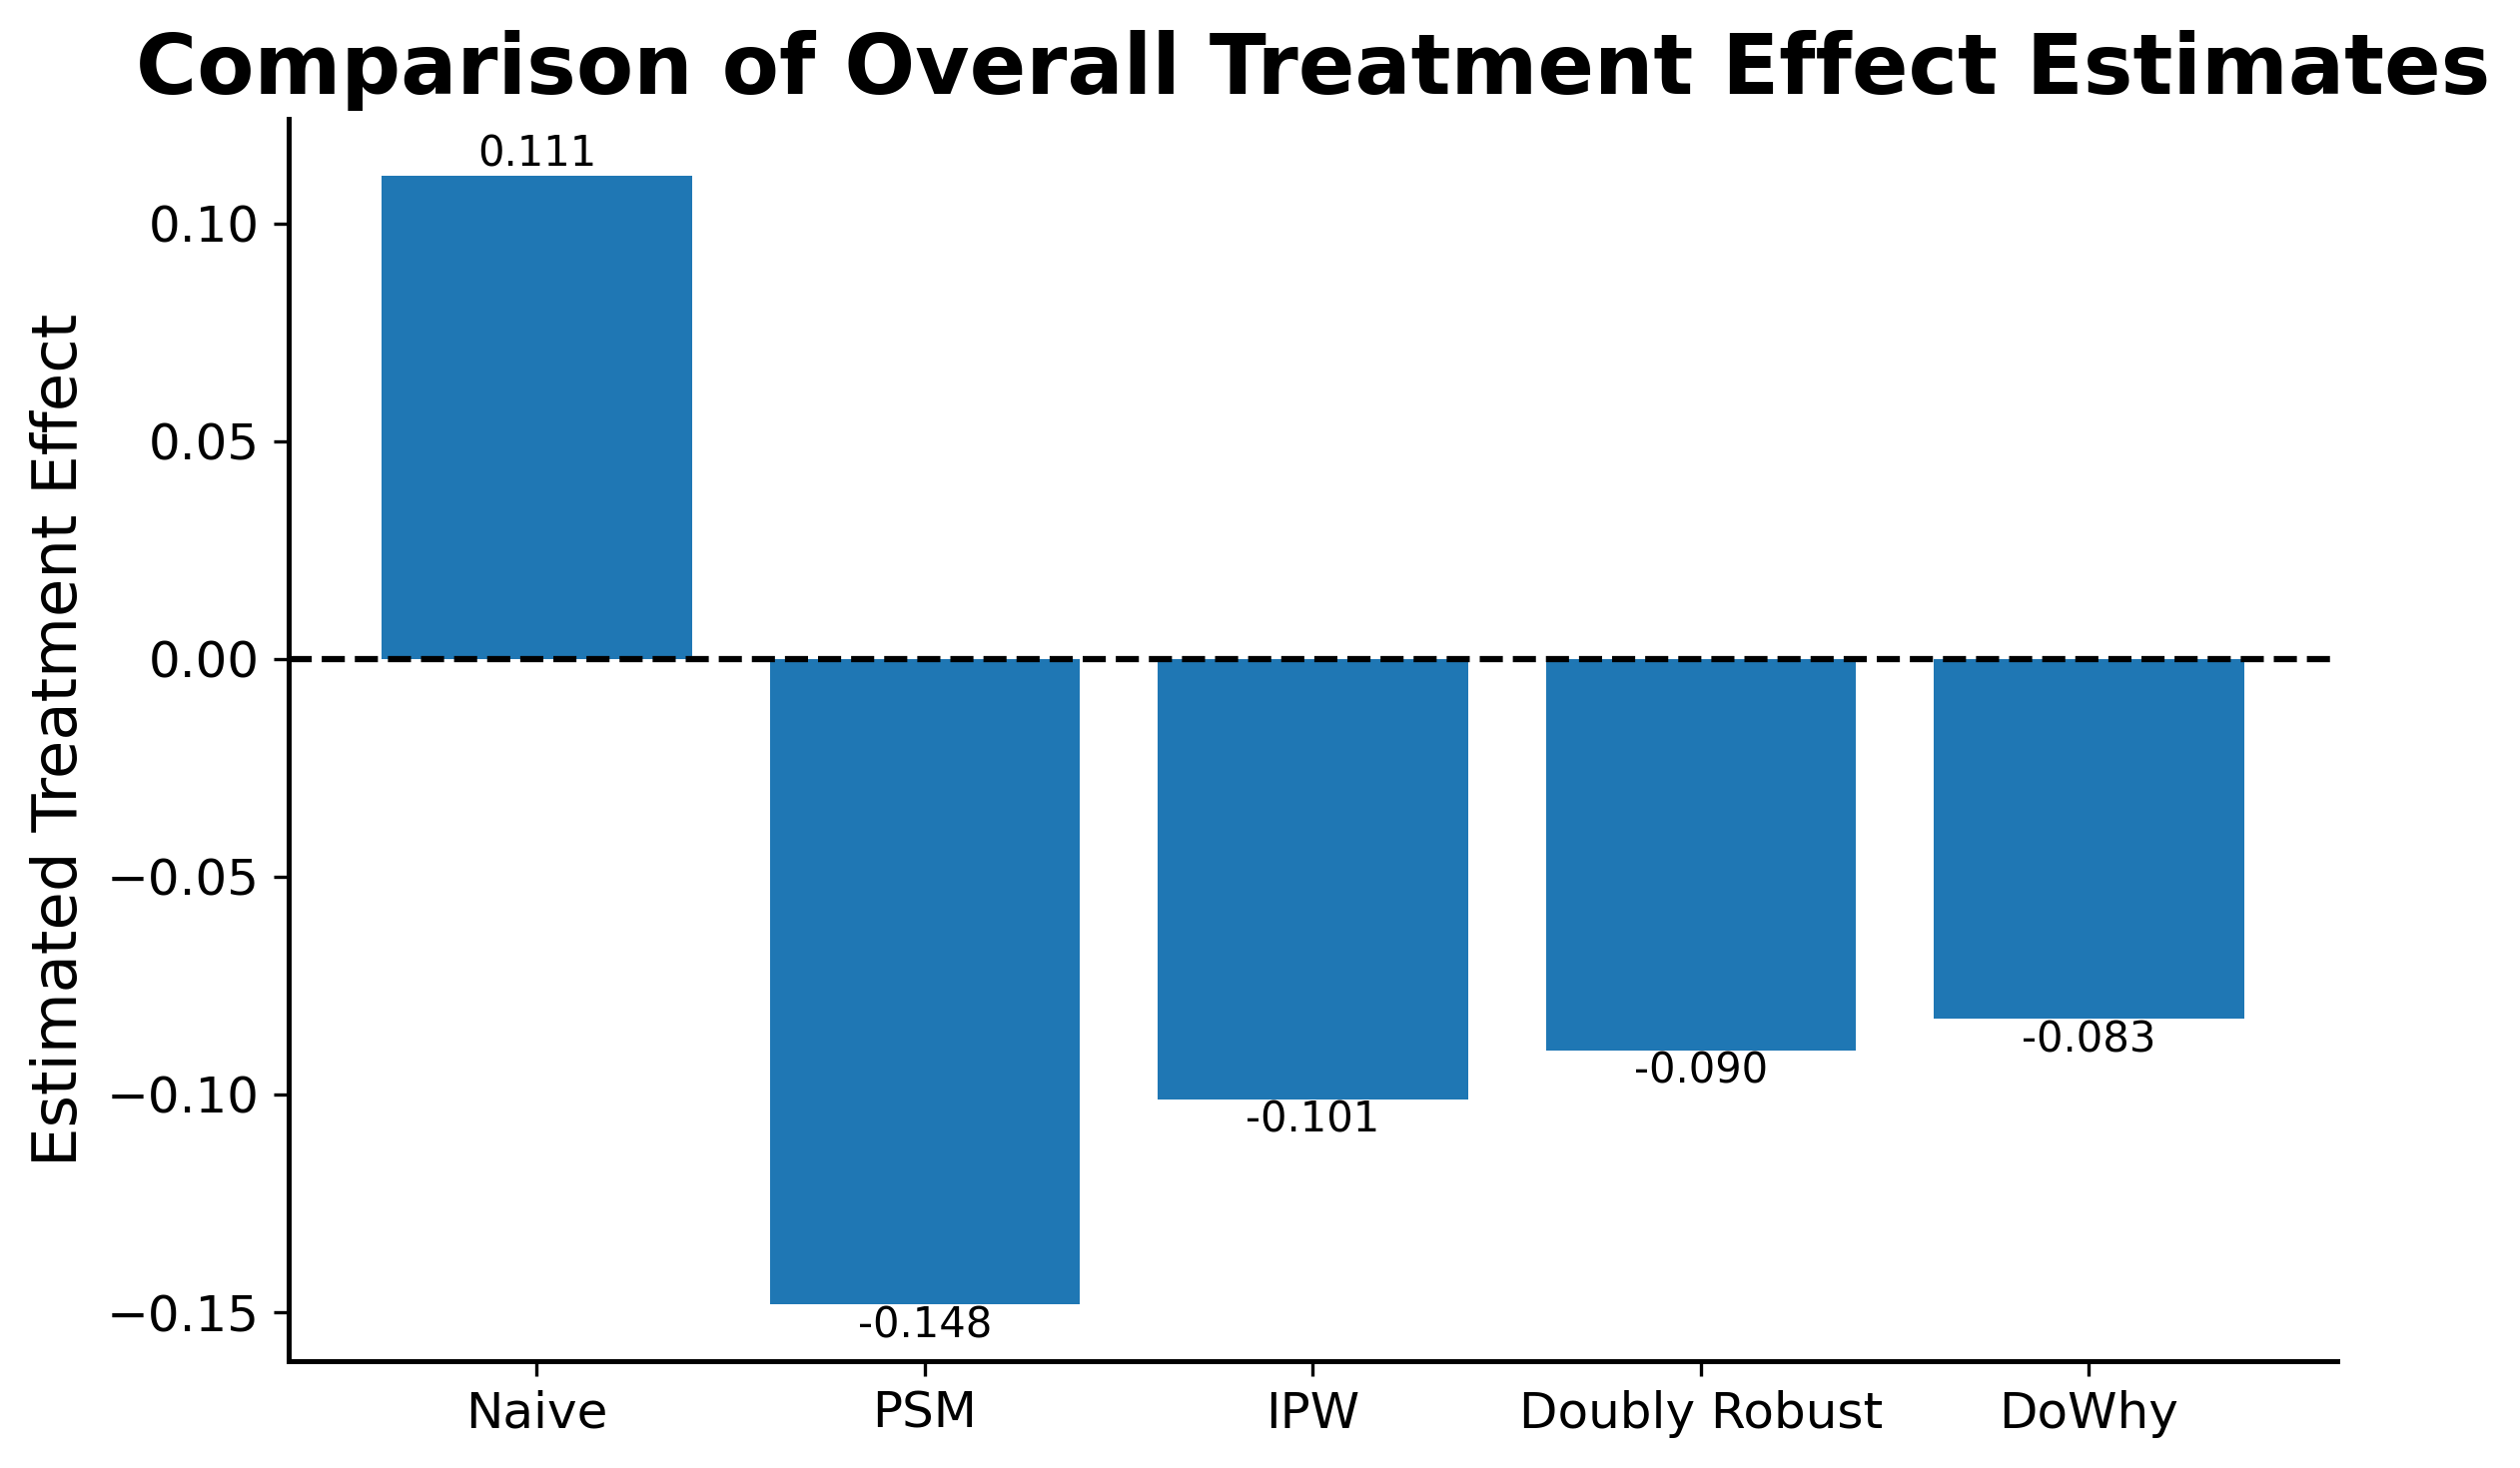

In [145]:
plt.figure(figsize=(8,5))

bars = plt.bar(

    comparison["Method"],

    comparison["Estimated Effect"]

)

plt.axhline(

    0,

    color="black",

    linestyle="--"

)

plt.ylabel("Estimated Treatment Effect")

plt.title("Comparison of Overall Treatment Effect Estimates")

for bar in bars:

    h = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        h,

        f"{h:.3f}",

        ha="center",

        va="bottom" if h >= 0 else "top"

    )

plt.tight_layout()

plt.show()

In [146]:
overall_results = pd.DataFrame({

    "Method":[

        "Naive",

        "PSM",

        "IPW",

        "Doubly Robust",

        "DoWhy"

    ],

    "Estimated Effect":[

        naive_effect,

        psm_effect,

        ipw_effect,

        dr_effect,

        dowhy_effect

    ]

})

display(overall_results.round(4))

,Method,Estimated Effect
0,Naive,0.1111
1,PSM,-0.1482
2,IPW,-0.1011
3,Doubly Robust,-0.0899
4,DoWhy,-0.0826


# 4. Customer Segmentation

While the previous section estimated the overall average treatment effect, different customer groups may respond differently to retention offers.

To investigate heterogeneous treatment effects, customers are first segmented into homogeneous groups using K-Means clustering. Feature selection is performed using Random Forest-based confounder importance to identify the most informative variables for clustering.

The workflow consists of:

- Feature importance estimation
- Confounder ranking
- Feature selection
- K-Means clustering
- Cluster evaluation
- Customer profiling

In [147]:
X_rank = df[BASELINE_COLS].copy()

num_cols = [
    c for c in BASELINE_COLS
    if pd.api.types.is_numeric_dtype(X_rank[c])
]

cat_cols = [
    c for c in BASELINE_COLS
    if c not in num_cols
]

for c in num_cols:

    X_rank[c] = pd.to_numeric(
        X_rank[c],
        errors="coerce"
    ).fillna(
        X_rank[c].median()
    )

for c in cat_cols:

    X_rank[c] = (
        X_rank[c]
        .fillna("Missing")
        .astype(str)
    )

X_dummy = pd.get_dummies(
    X_rank,
    drop_first=True
)

In [148]:
rf_treat = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_treat.fit(
    X_dummy,
    df[TREATMENT]
)

rf_outcome = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_outcome.fit(
    X_dummy,
    df[OUTCOME]
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [149]:
treat_imp = pd.Series(
    rf_treat.feature_importances_,
    index=X_dummy.columns
)

outcome_imp = pd.Series(
    rf_outcome.feature_importances_,
    index=X_dummy.columns
)

In [150]:
def original_feature(col):

    for base in BASELINE_COLS:

        if col == base:
            return base

        if col.startswith(base + "_"):
            return base

    return col

importance_df = pd.DataFrame({

    "Treatment": treat_imp,

    "Outcome": outcome_imp

})

importance_df["Feature"] = (
    importance_df.index
    .map(original_feature)
)

importance_df = (

    importance_df

    .groupby("Feature")[["Treatment","Outcome"]]

    .sum()

)

In [151]:
importance_df["Confounder_Score"] = (

    2 *

    importance_df["Treatment"]

    *

    importance_df["Outcome"]

) / (

    importance_df["Treatment"]

    +

    importance_df["Outcome"]

    +

    1e-9

)

importance_df = importance_df.sort_values(

    "Confounder_Score",

    ascending=False

)

display(
    importance_df.round(4)
)

,Treatment,Outcome,Confounder_Score
Feature,,,
MonthlyCharges,0.1785,0.2081,0.1922
TotalCharges,0.1786,0.2079,0.1921
tenure,0.1501,0.1493,0.1497
PaymentMethod,0.0727,0.0591,0.0652
Contract,0.0978,0.0339,0.0503
InternetService,0.0541,0.0308,0.0393
gender,0.0274,0.0331,0.0300
PaperlessBilling,0.0245,0.0275,0.0259
TechSupport,0.0253,0.0256,0.0255


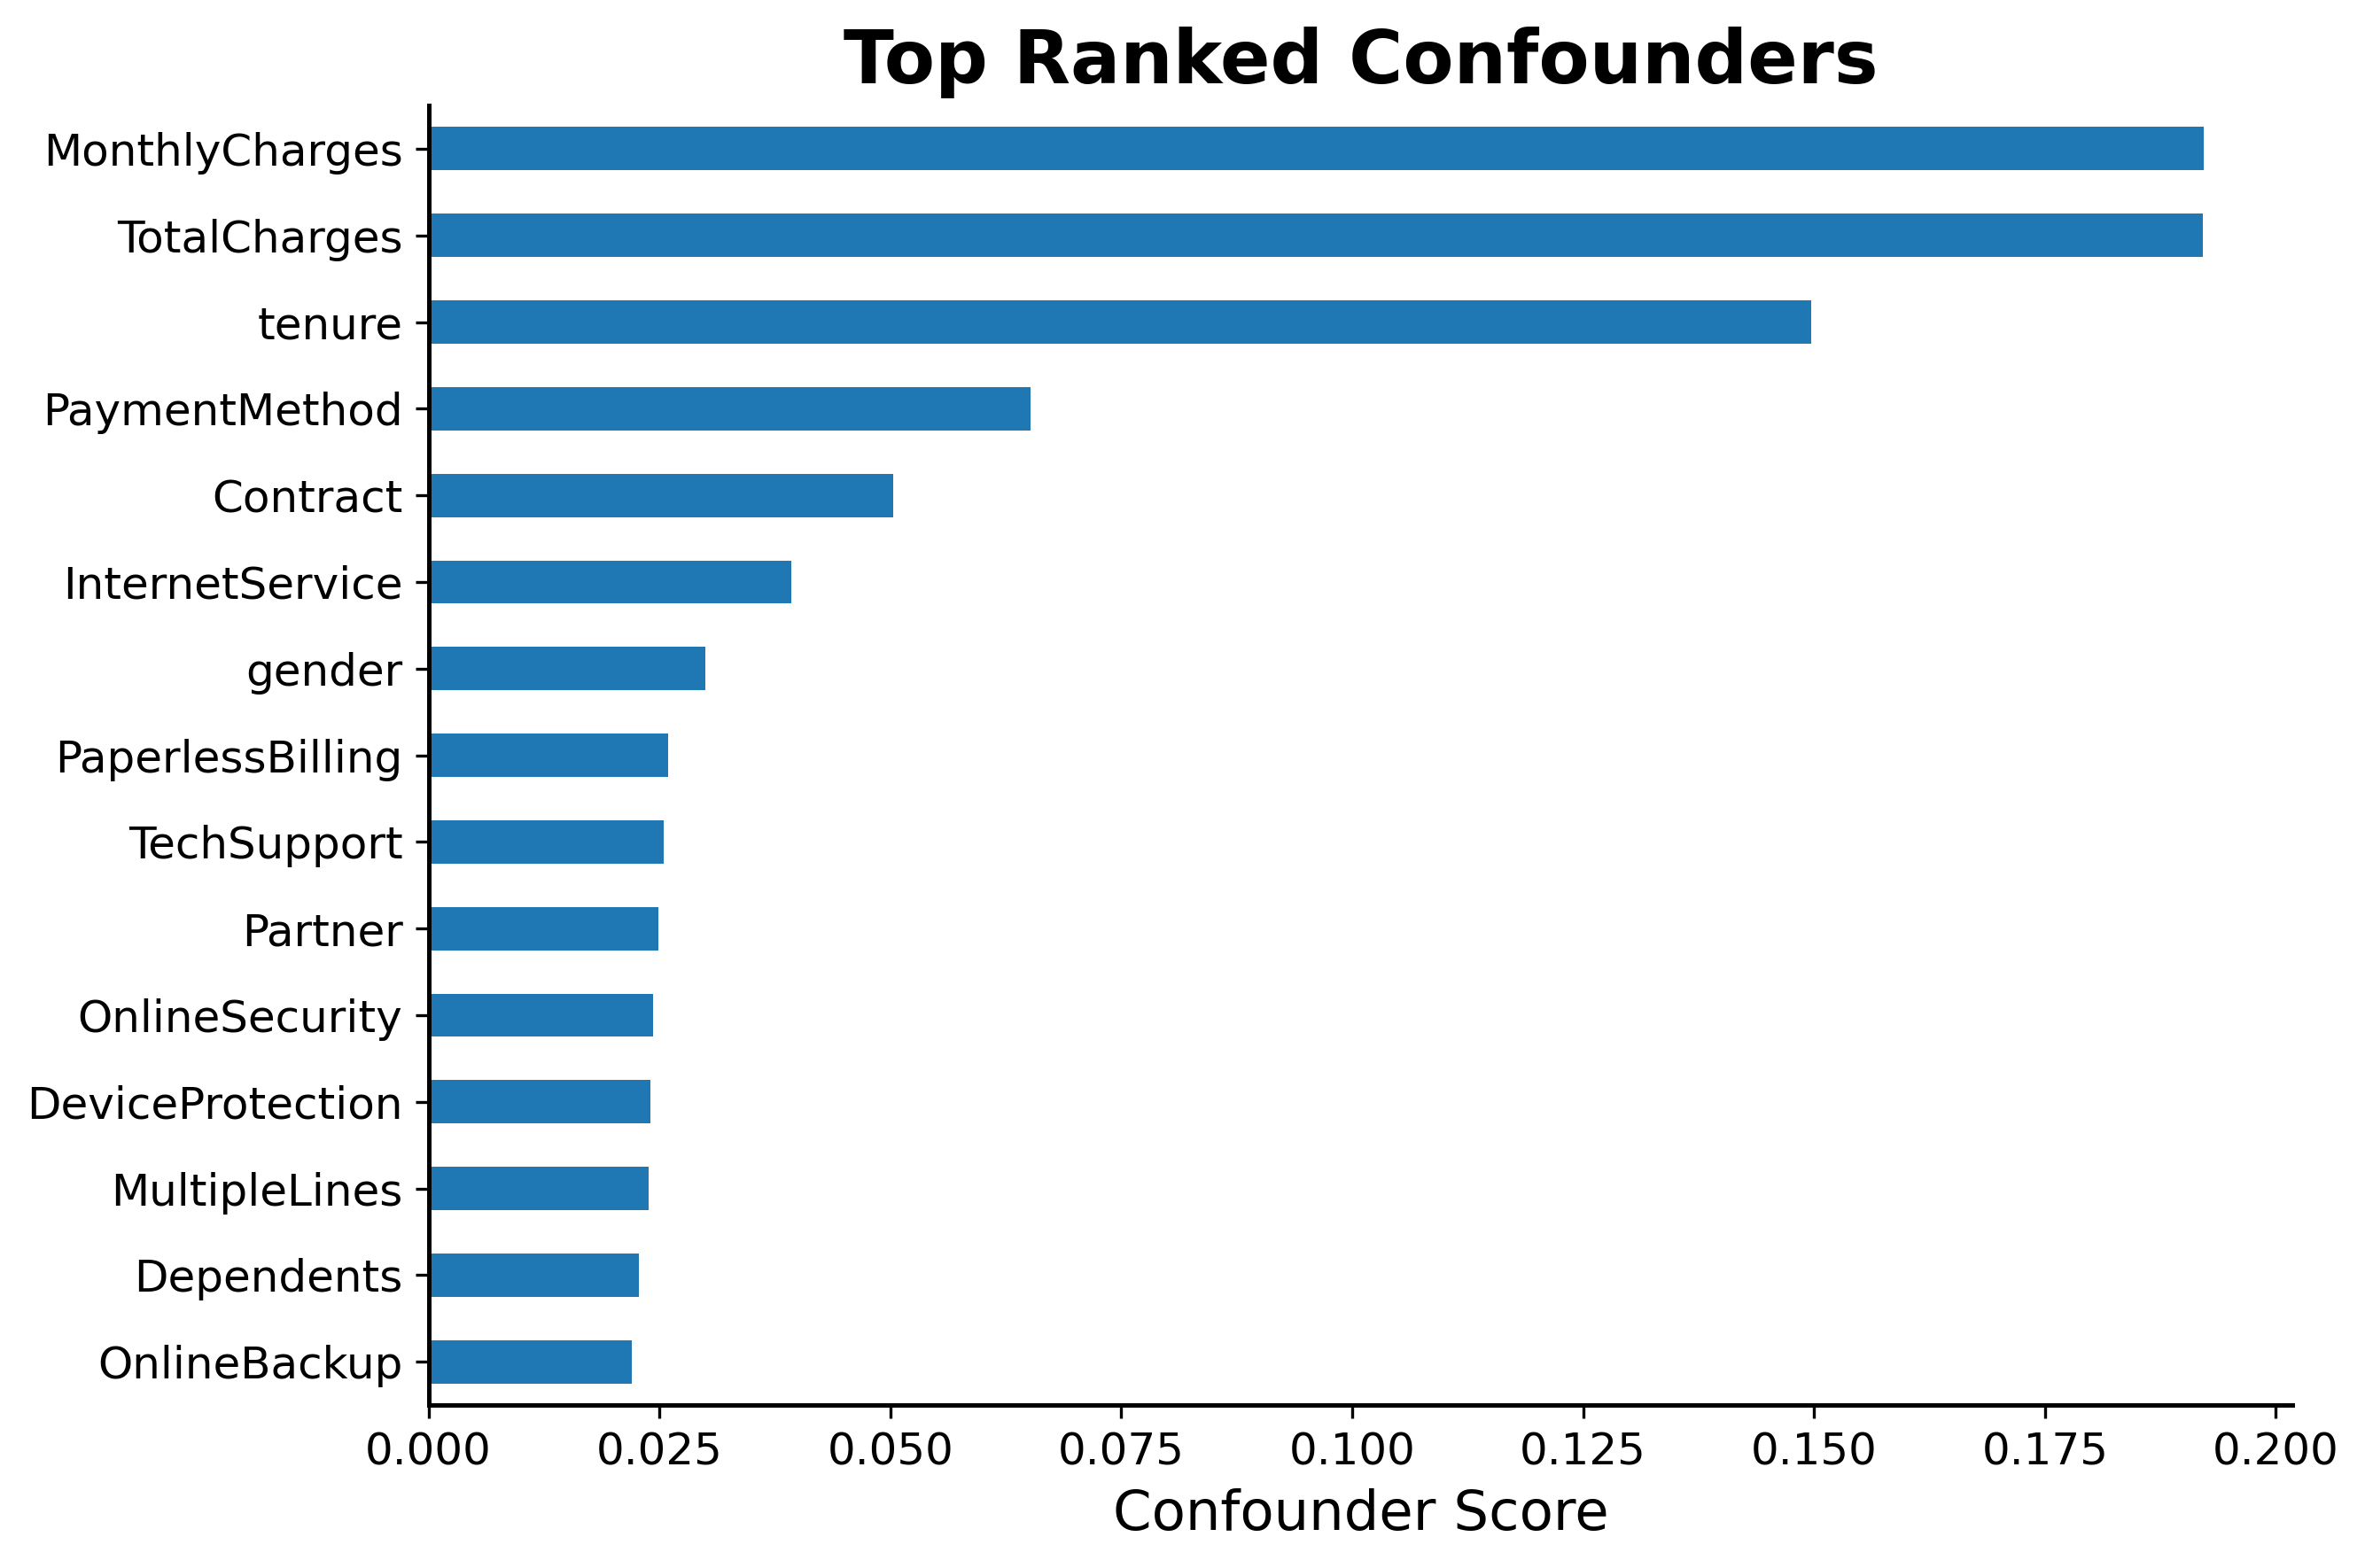

In [152]:
plt.figure(figsize=(9,6))

importance_df["Confounder_Score"]\
.head(15)\
.sort_values()\
.plot.barh()

plt.xlabel("Confounder Score")

plt.ylabel("")

plt.title("Top Ranked Confounders")

plt.tight_layout()

plt.show()

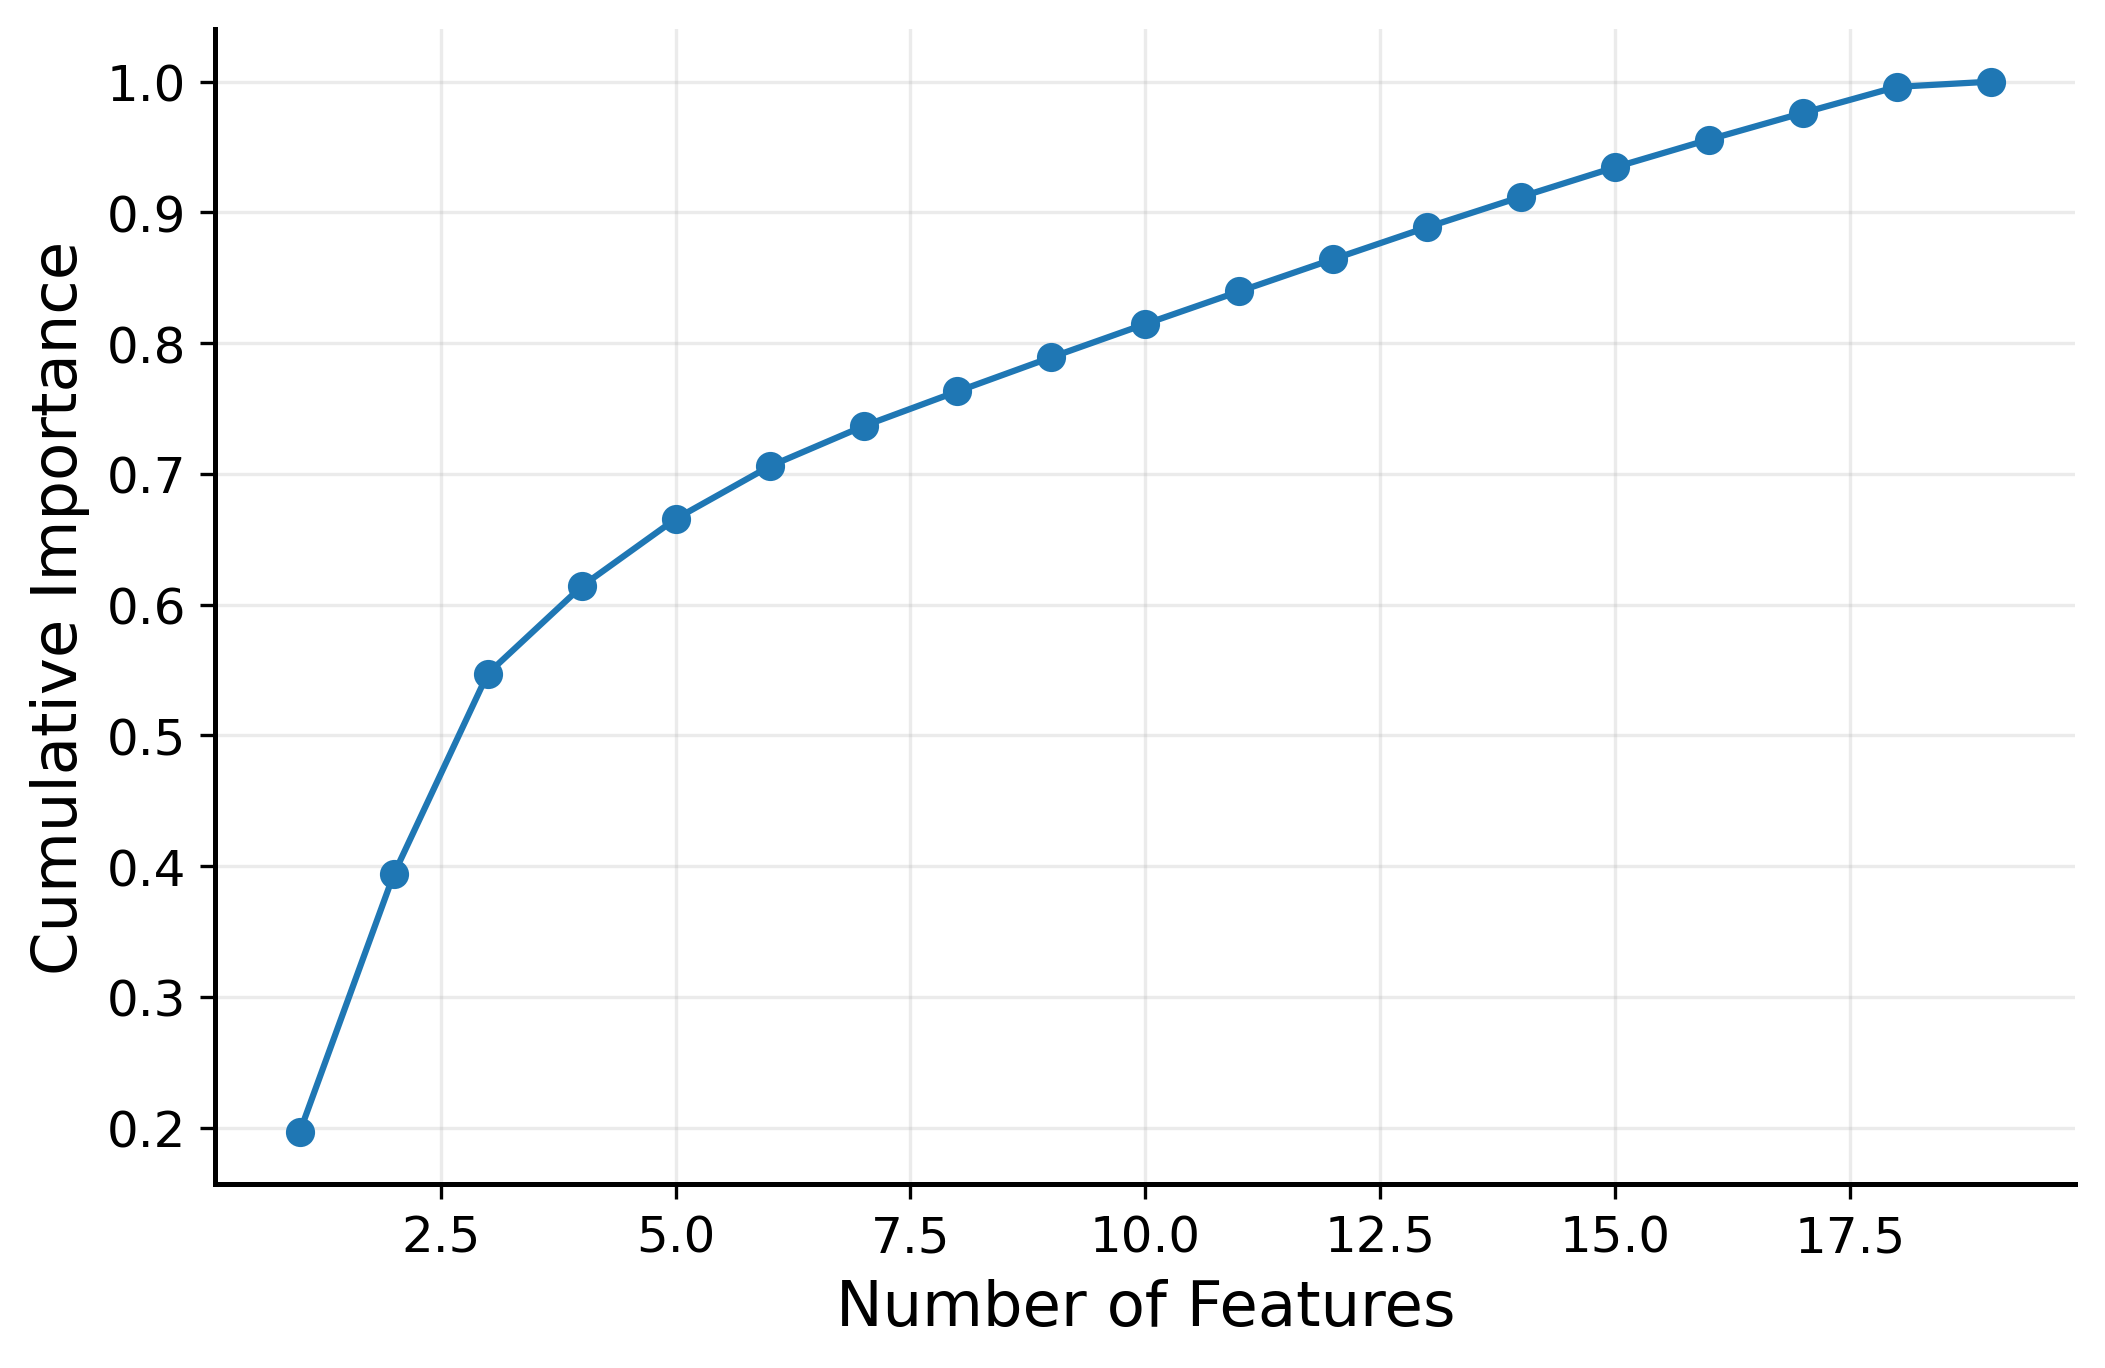

In [153]:
importance_df["Cumulative"] = (

    importance_df["Confounder_Score"]

    .cumsum()

    /

    importance_df["Confounder_Score"].sum()

)

plt.figure(figsize=(8,5))

plt.plot(

    range(

        1,

        len(importance_df)+1

    ),

    importance_df["Cumulative"],

    marker="o"

)

plt.xlabel("Number of Features")

plt.ylabel("Cumulative Importance")

plt.grid(True)

plt.show()

## Feature Selection

The highest-ranked confounding variables are selected for customer segmentation. These variables are strongly associated with both treatment assignment and churn, making them suitable for identifying meaningful customer groups.

In [154]:
TOP_N = 10

selected_features = (

    importance_df

    .head(TOP_N)

    .index

    .tolist()

)

print(selected_features)

['MonthlyCharges', 'TotalCharges', 'tenure', 'PaymentMethod', 'Contract', 'InternetService', 'gender', 'PaperlessBilling', 'TechSupport', 'Partner']


In [155]:
X_raw = df[selected_features].copy()

num_cols = [

    c

    for c in selected_features

    if pd.api.types.is_numeric_dtype(df[c])

]

cat_cols = [

    c

    for c in selected_features

    if c not in num_cols

]

preprocess = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            num_cols

        ),

        (

            "cat",

            OneHotEncoder(

                handle_unknown="ignore"

            ),

            cat_cols

        )

    ]

)

X_cluster = preprocess.fit_transform(
    X_raw
)

## Choosing the Optimal Number of Clusters

Multiple clustering metrics are evaluated to determine the most appropriate number of customer segments.

In [156]:
rows = []

for k in range(2,11):

    km = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=20

    )

    labels = km.fit_predict(
        X_cluster
    )

    rows.append({

        "K":k,

        "WCSS":km.inertia_,

        "Silhouette":silhouette_score(

            X_cluster,

            labels

        ),

        "Calinski_Harabasz":

        calinski_harabasz_score(

            X_cluster,

            labels

        ),

        "Davies_Bouldin":

        davies_bouldin_score(

            X_cluster,

            labels

        )

    })

eval_df = pd.DataFrame(rows)

display(eval_df.round(3))

,K,WCSS,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,2,36865.434,0.241,2489.998,1.575
1,3,29558.144,0.250,2422.769,1.464
2,4,26497.192,0.218,2072.557,1.673
3,5,24421.478,0.204,1835.846,1.795
4,6,22749.687,0.205,1679.805,1.743
5,7,21658.011,0.187,1529.299,1.699
6,8,20787.167,0.184,1407.650,1.798
7,9,20068.190,0.171,1307.140,1.875
8,10,19574.699,0.172,1210.728,1.955


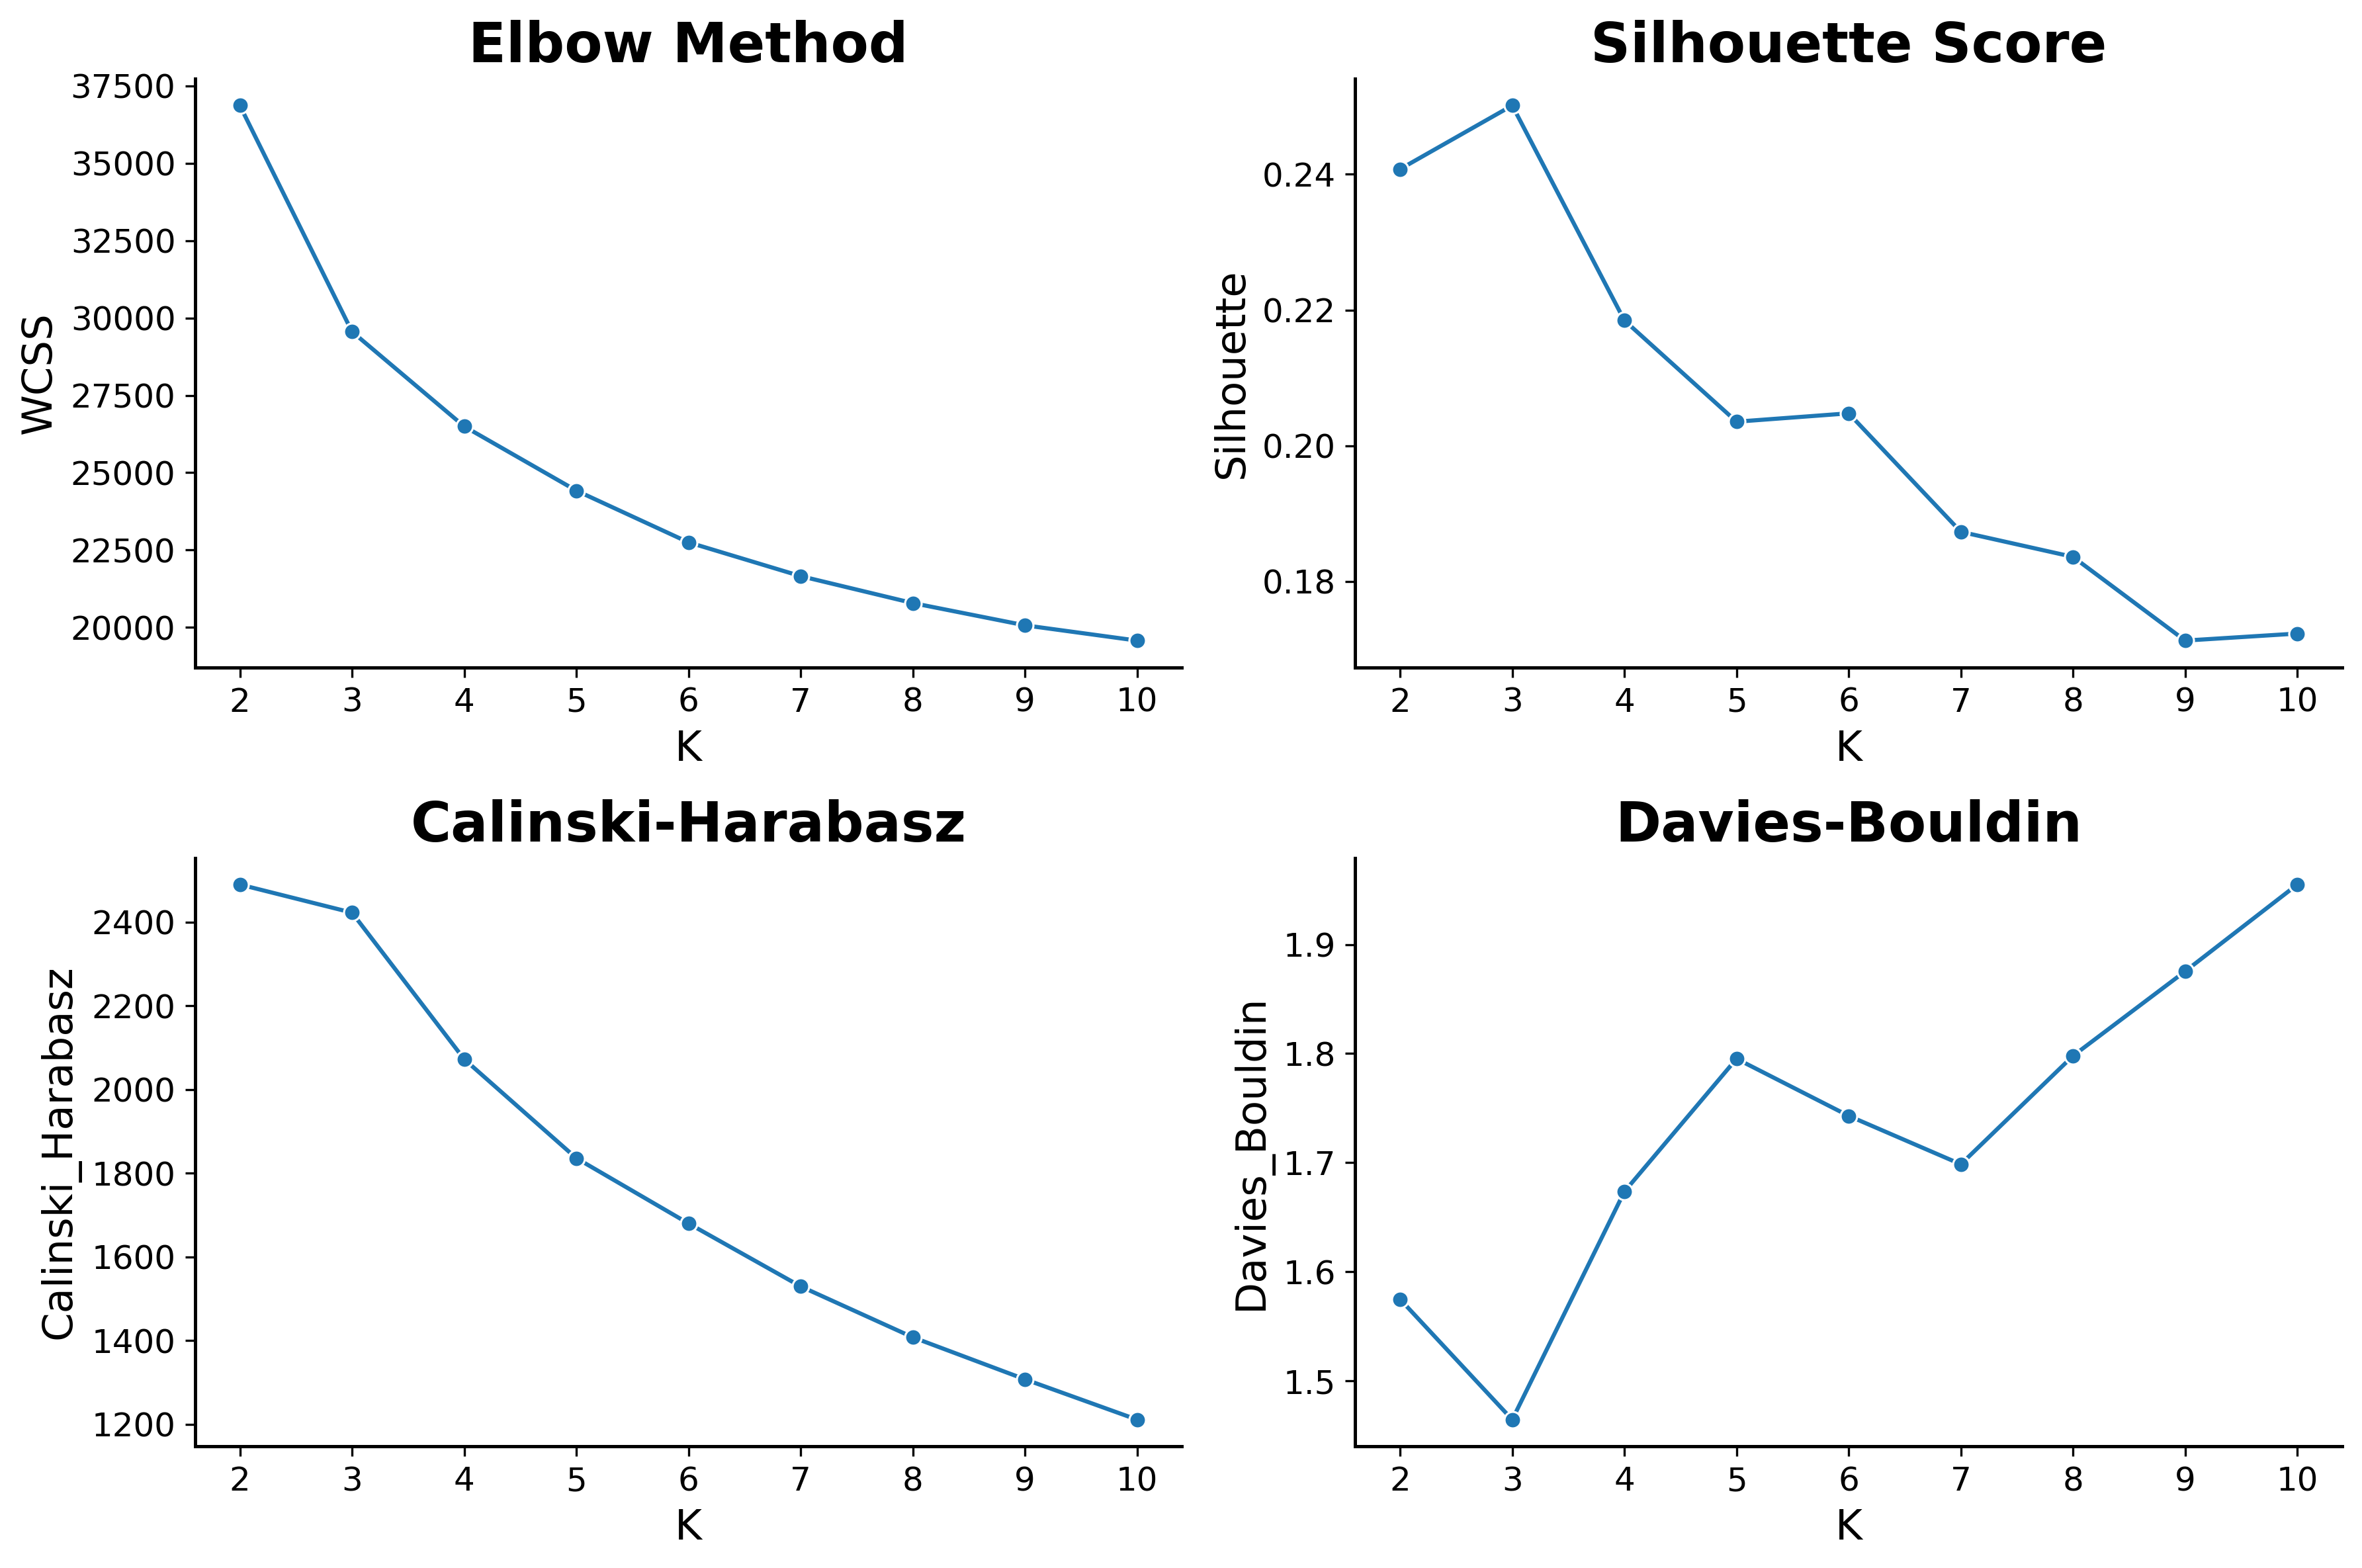

In [157]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

sns.lineplot(
    data=eval_df,
    x="K",
    y="WCSS",
    marker="o",
    ax=axes[0,0]
)

axes[0,0].set_title("Elbow Method")

sns.lineplot(
    data=eval_df,
    x="K",
    y="Silhouette",
    marker="o",
    ax=axes[0,1]
)

axes[0,1].set_title("Silhouette Score")

sns.lineplot(
    data=eval_df,
    x="K",
    y="Calinski_Harabasz",
    marker="o",
    ax=axes[1,0]
)

axes[1,0].set_title("Calinski-Harabasz")

sns.lineplot(
    data=eval_df,
    x="K",
    y="Davies_Bouldin",
    marker="o",
    ax=axes[1,1]
)

axes[1,1].set_title("Davies-Bouldin")

plt.tight_layout()

plt.show()

## Final Customer Segments

Based on the cluster evaluation metrics, three customer segments were selected for subsequent heterogeneous treatment effect analysis.

In [158]:
FINAL_K = 3

km = KMeans(

    n_clusters=FINAL_K,

    random_state=42,

    n_init=20

)

df["Customer_Segment"] = km.fit_predict(
    X_cluster
)

In [159]:
segment_counts = (

    df["Customer_Segment"]

    .value_counts()

    .sort_index()

    .reset_index()

)

segment_counts.columns = [

    "Customer_Segment",

    "Customers"

]

segment_counts["Percent"] = (

    segment_counts["Customers"]

    /

    len(df)

    *

    100

).round(2)

display(segment_counts)

,Customer_Segment,Customers,Percent
0,0,1593,22.62
1,1,2292,32.54
2,2,3158,44.84


In [160]:
segment_name_map = {

    0:"Growth Customers",

    1:"Budget Stable Customers",

    2:"Premium At-Risk Customers"

}

df["Segment_Name"] = df["Customer_Segment"].map(
    segment_name_map
)

display(

    df[

        [

            "Customer_Segment",

            "Segment_Name"

        ]

    ]

    .drop_duplicates()

    .sort_values(

        "Customer_Segment"

    )

)

,Customer_Segment,Segment_Name
3,0,Growth Customers
8,1,Budget Stable Customers
0,2,Premium At-Risk Customers


## Customer Segment Profiling

After clustering, each customer segment is profiled using demographic, financial, treatment, and churn characteristics.

These summaries help interpret the behavioral differences between customer groups and provide business context for the subsequent heterogeneous treatment effect analysis.

In [161]:
segment_profile = (

    df

    .groupby("Segment_Name")

    .agg(

        Customers=("customerID", "count"),

        Avg_Tenure=("tenure", "mean"),

        Avg_MonthlyCharges=("MonthlyCharges", "mean"),

        Avg_TotalCharges=("TotalCharges", "mean"),

        Offer_Rate=(TREATMENT, "mean"),

        Churn_Rate=(OUTCOME, "mean"),

        Avg_Customer_Value=("Customer_Value", "mean"),

        Avg_Offer_Cost=("Offer_Cost", "mean"),

        Avg_Revenue_Saved=("Expected_Revenue_Saved", "mean"),

        Avg_Net_Value=("Expected_Net_Value", "mean")

    )

)

display(segment_profile.round(2))

,Customers,Avg_Tenure,Avg_MonthlyCharges,Avg_TotalCharges,Offer_Rate,Churn_Rate,Avg_Customer_Value,Avg_Offer_Cost,Avg_Revenue_Saved,Avg_Net_Value
Segment_Name,,,,,,,,,,
Budget Stable Customers,2292,57.98,88.31,5119.81,0.48,0.17,600.33,4.76,32.74,27.98
Growth Customers,1593,30.84,21.73,697.60,0.33,0.08,350.09,3.27,4.24,0.97
Premium At-Risk Customers,3158,14.56,69.38,1021.42,0.74,0.33,520.99,7.44,84.17,76.74


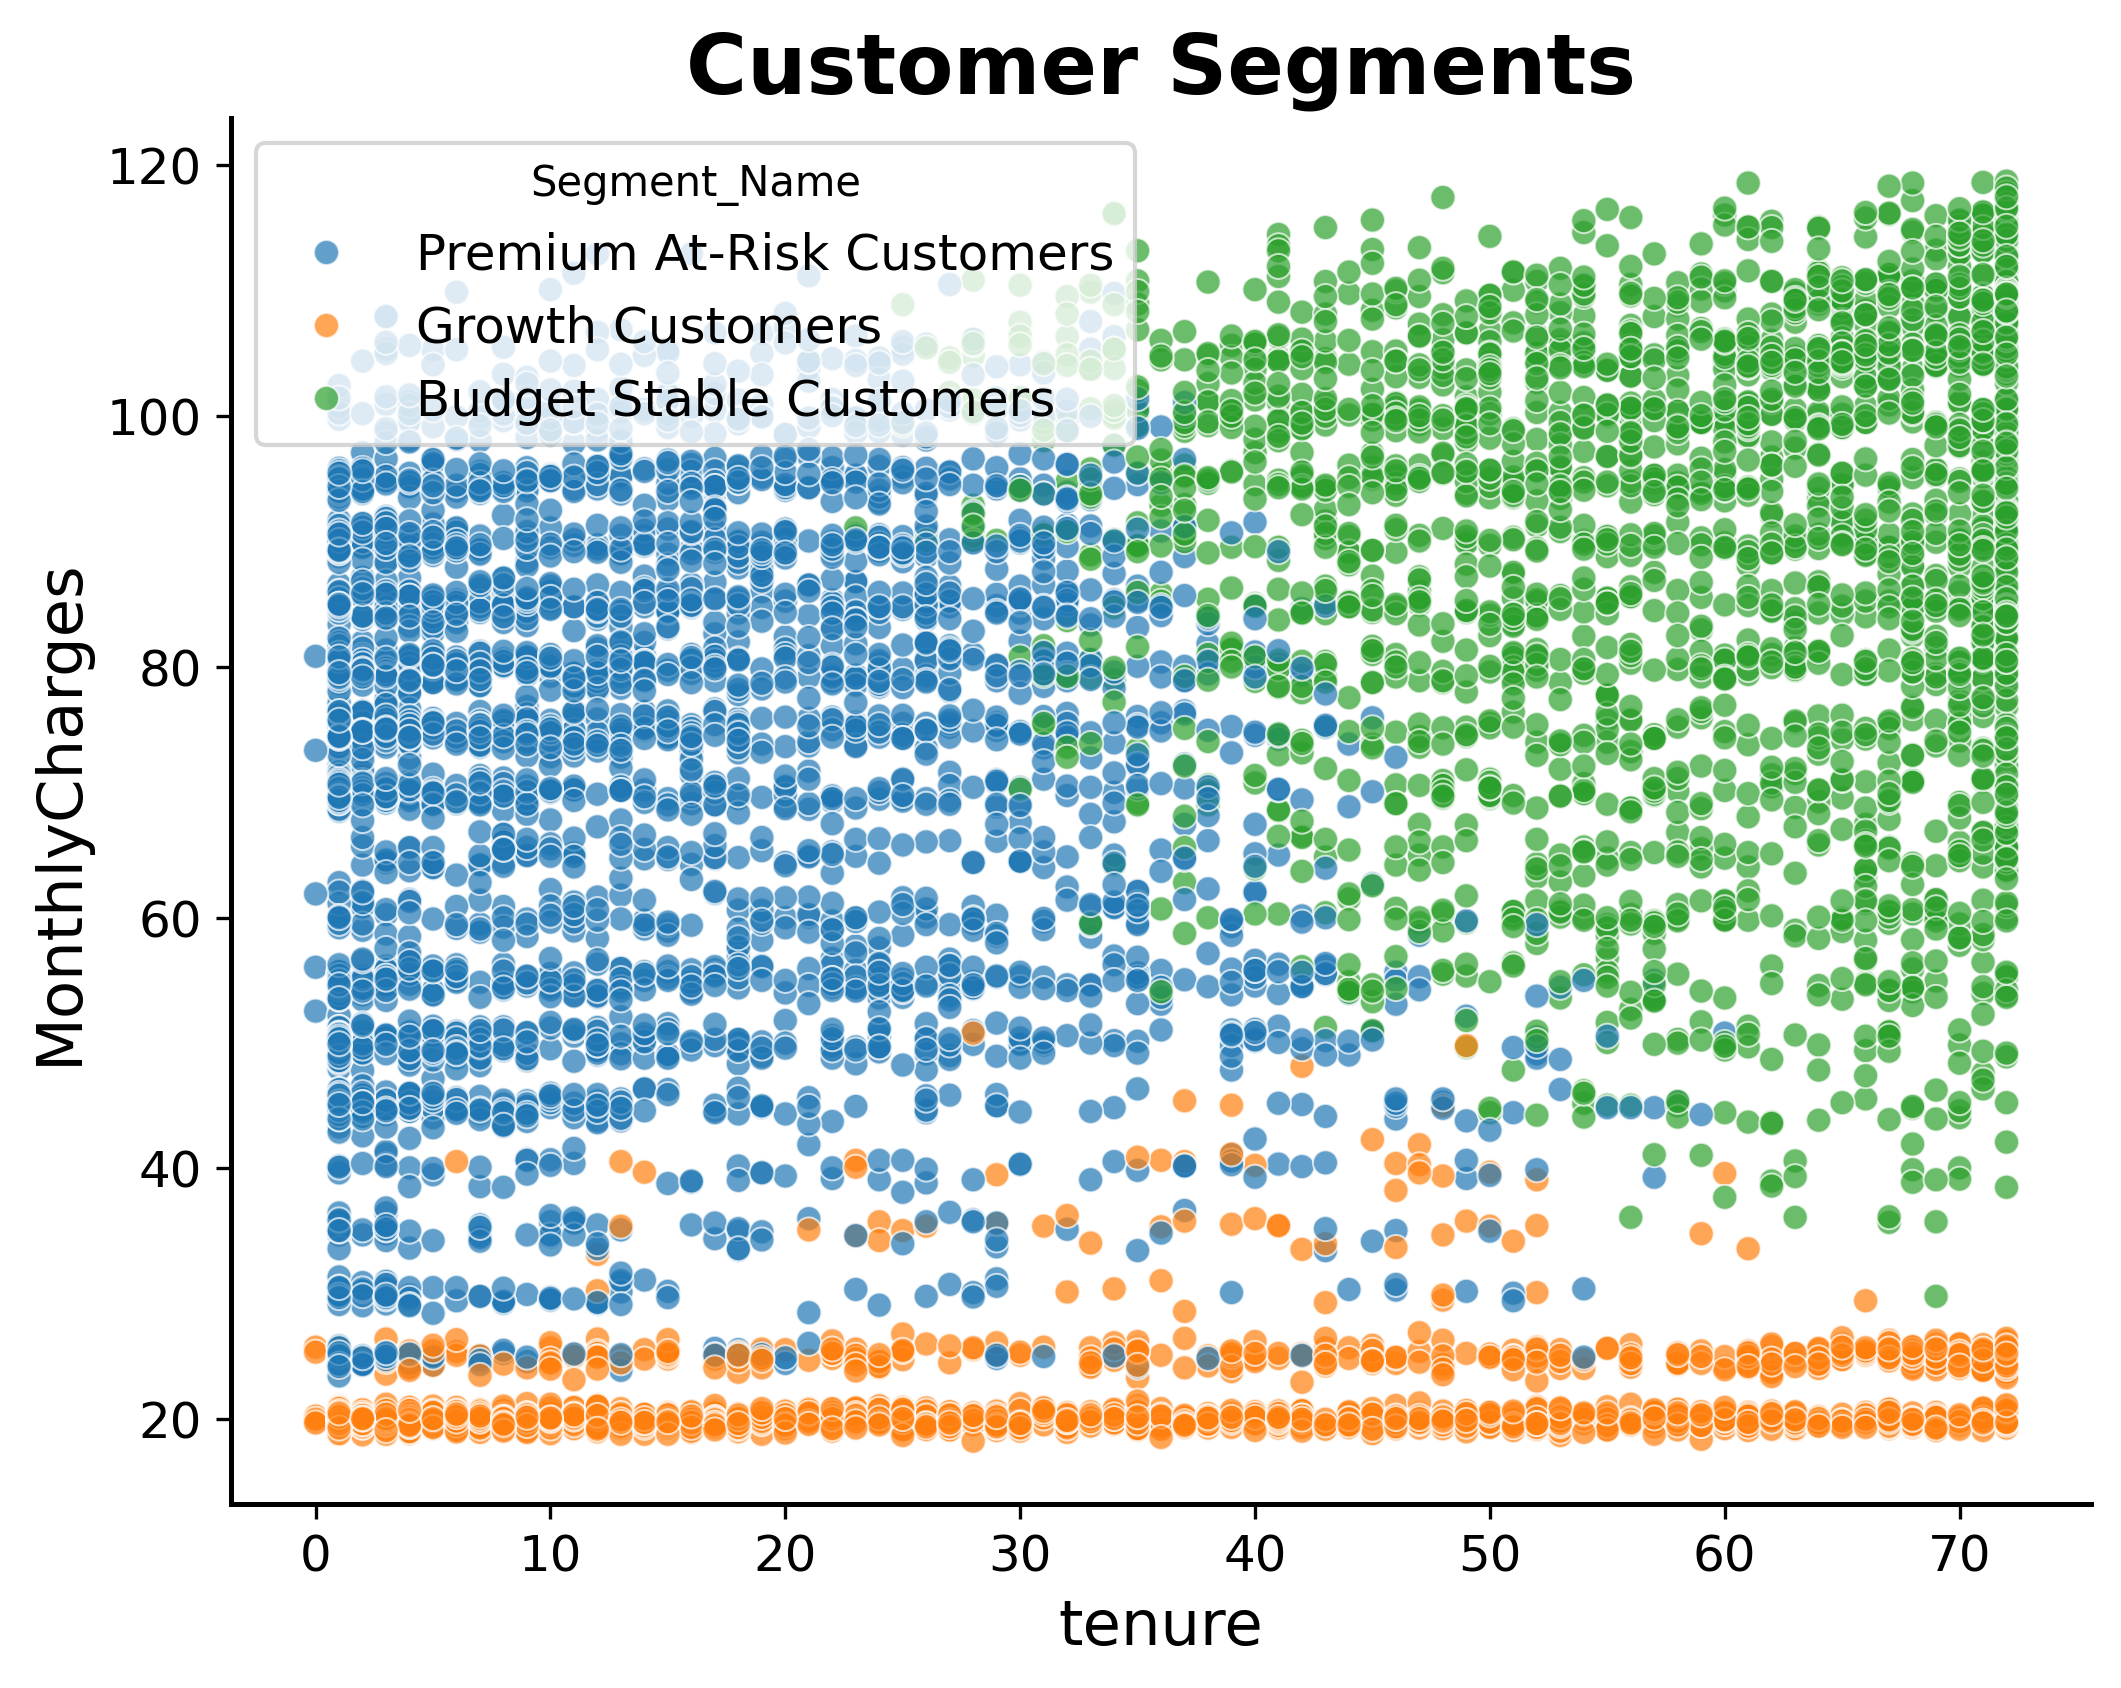

In [162]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="tenure",

    y="MonthlyCharges",

    hue="Segment_Name",

    alpha=0.7

)

plt.title("Customer Segments")

plt.show()

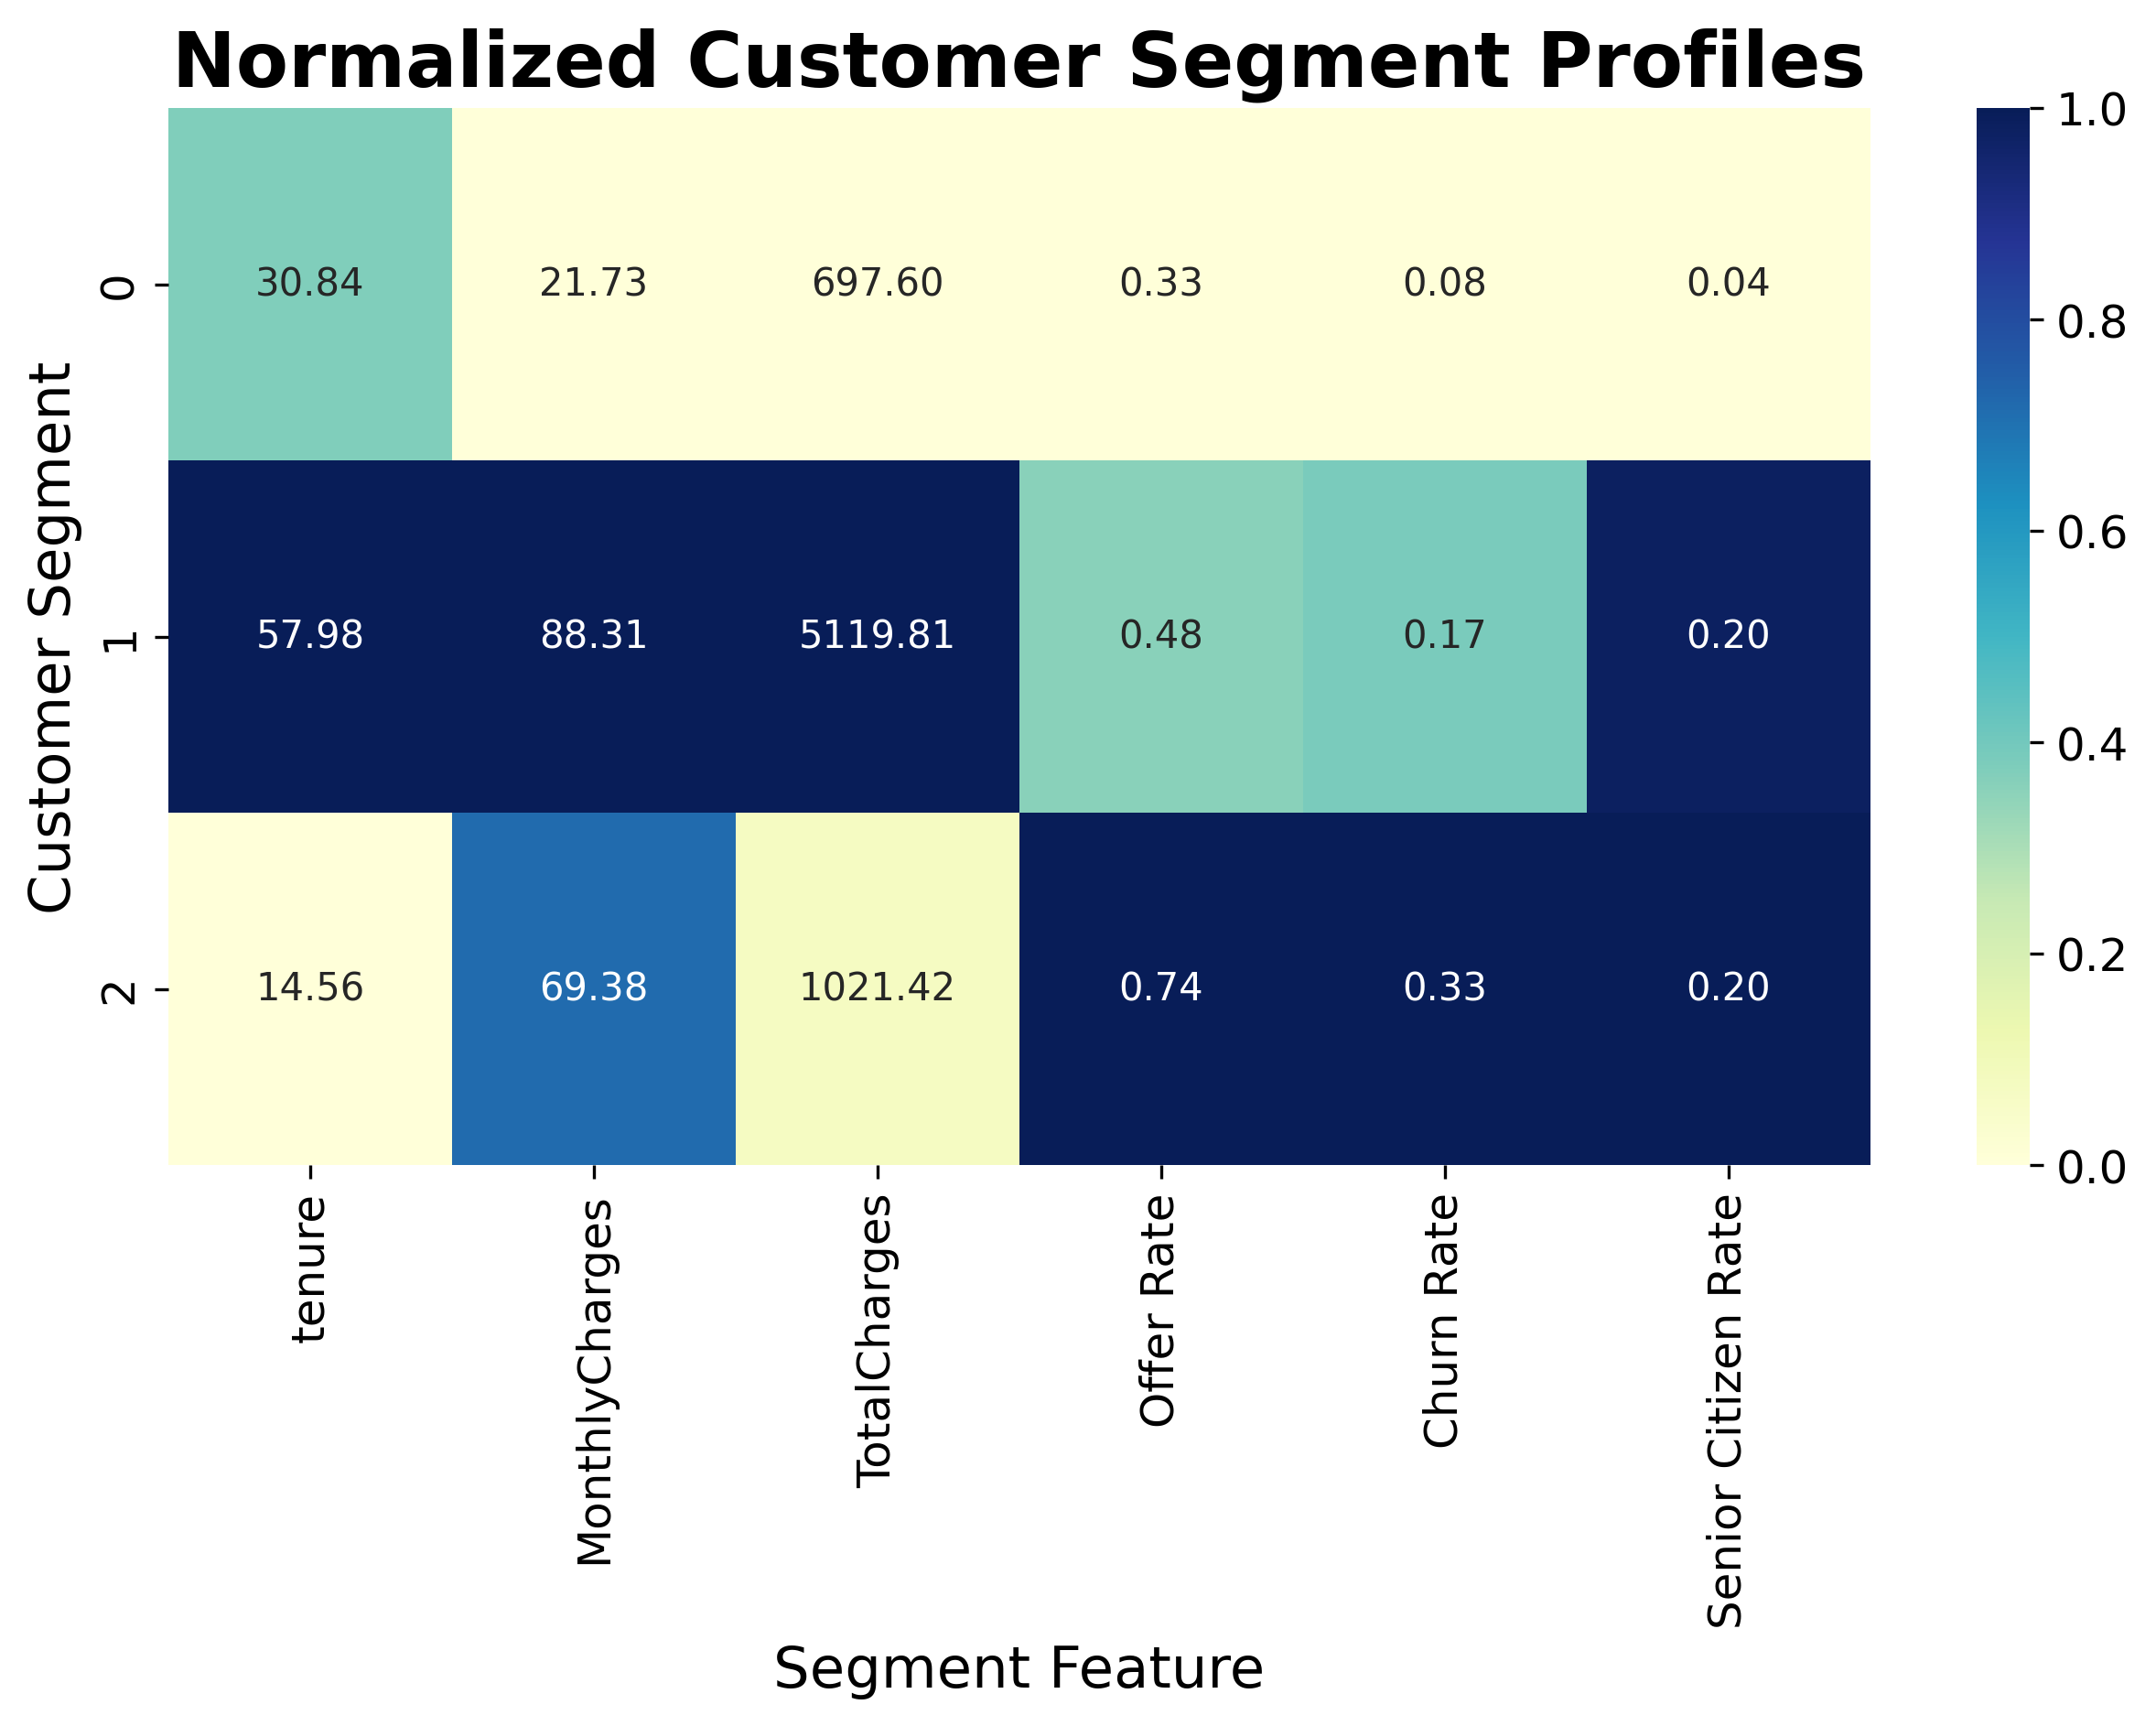

In [163]:
from sklearn.preprocessing import MinMaxScaler

radar_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    TREATMENT,
    OUTCOME,
    "SeniorCitizen"
]

radar_cols = [c for c in radar_cols if c in df.columns]

segment_profile_for_plot = (
    df
    .groupby("Customer_Segment")[radar_cols]
    .mean()
)

segment_profile_for_plot = segment_profile_for_plot.rename(columns={
    TREATMENT: "Offer Rate",
    OUTCOME: "Churn Rate",
    "SeniorCitizen": "Senior Citizen Rate"
})

scaler = MinMaxScaler()

heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(segment_profile_for_plot),
    columns=segment_profile_for_plot.columns,
    index=segment_profile_for_plot.index
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_scaled,
    annot=segment_profile_for_plot.round(2),
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Normalized Customer Segment Profiles")
plt.xlabel("Segment Feature")
plt.ylabel("Customer Segment")
plt.show()

# 5. Segment-wise Causal Analysis

The previous analysis estimated the average treatment effect across the entire customer population. However, customers belonging to different segments may respond differently to retention offers.

This section estimates the causal treatment effect separately for each customer segment using the same causal inference methods applied earlier.

The objective is to identify which customer groups benefit most from the retention campaign and to support targeted intervention strategies.

In [164]:
causal_df = df[[TREATMENT, OUTCOME, "Customer_Segment"] + BASELINE_COLS].copy()

for c in BASELINE_COLS:
    if pd.api.types.is_numeric_dtype(causal_df[c]):
        causal_df[c] = pd.to_numeric(causal_df[c], errors="coerce").fillna(causal_df[c].median())
    else:
        causal_df[c] = causal_df[c].fillna("Missing").astype(str)

causal_df = pd.get_dummies(
    causal_df,
    columns=[c for c in BASELINE_COLS if not pd.api.types.is_numeric_dtype(df[c])],
    drop_first=True,
    dtype=float
)

causal_df[TREATMENT] = causal_df[TREATMENT].astype(int)
causal_df[OUTCOME] = causal_df[OUTCOME].astype(int)
causal_df["Customer_Segment"] = causal_df["Customer_Segment"].astype(int)

confounders = [
    c for c in causal_df.columns
    if c not in [TREATMENT, OUTCOME, "Customer_Segment"]
]

print("Causal data shape:", causal_df.shape)
print("Number of confounders:", len(confounders))

Causal data shape: (7043, 33)
Number of confounders: 30


In [165]:
results = []

for seg in sorted(causal_df["Customer_Segment"].unique()):
    seg_df = causal_df[causal_df["Customer_Segment"] == seg].copy()

    n = len(seg_df)
    treated = seg_df[TREATMENT].sum()
    control = n - treated

    if treated < 20 or control < 20:
        print("Skipped: not enough treated/control customers.")
        results.append({
            "Segment": seg,
            "N": n,
            "Treated": treated,
            "Control": control,
            "Naive_Diff": np.nan,
            "DoWhy_Effect": np.nan,
            "Status": "Skipped"
        })
        continue

    naive_treated = seg_df.loc[seg_df[TREATMENT] == 1, OUTCOME].mean()
    naive_control = seg_df.loc[seg_df[TREATMENT] == 0, OUTCOME].mean()
    naive_diff = naive_treated - naive_control

    try:
        model = CausalModel(
            data=seg_df,
            treatment=TREATMENT,
            outcome=OUTCOME,
            common_causes=confounders
        )

        estimand = model.identify_effect(proceed_when_unidentifiable=True)

        estimate = model.estimate_effect(
            estimand,
            method_name="backdoor.linear_regression"
        )

        refute = model.refute_estimate(
            estimand,
            estimate,
            method_name="random_common_cause"
        )

        results.append({
            "Segment": seg,
            "N": n,
            "Treated": treated,
            "Control": control,
            "Churn_Treated": naive_treated,
            "Churn_Control": naive_control,
            "Naive_Diff": naive_diff,
            "DoWhy_Effect": estimate.value,
            "Refuted_Effect": getattr(refute, "new_effect", np.nan),
            "Status": "Success"
        })

    except Exception as e:
        print("Failed:", e)
        results.append({
            "Segment": seg,
            "N": n,
            "Treated": treated,
            "Control": control,
            "Naive_Diff": naive_diff,
            "DoWhy_Effect": np.nan,
            "Status": "Failed"
        })

dowhy_results = pd.DataFrame(results).round(4)
display(dowhy_results)

,Segment,N,Treated,Control,Churn_Treated,Churn_Control,Naive_Diff,DoWhy_Effect,Refuted_Effect,Status
0,0,1593,521,1072,0.0998,0.0634,0.0364,-0.0122,-0.0121,Success
1,1,2292,1091,1201,0.1934,0.1582,0.0352,-0.0676,-0.0677,Success
2,2,3158,2348,810,0.3467,0.2938,0.0529,-0.1477,-0.1478,Success


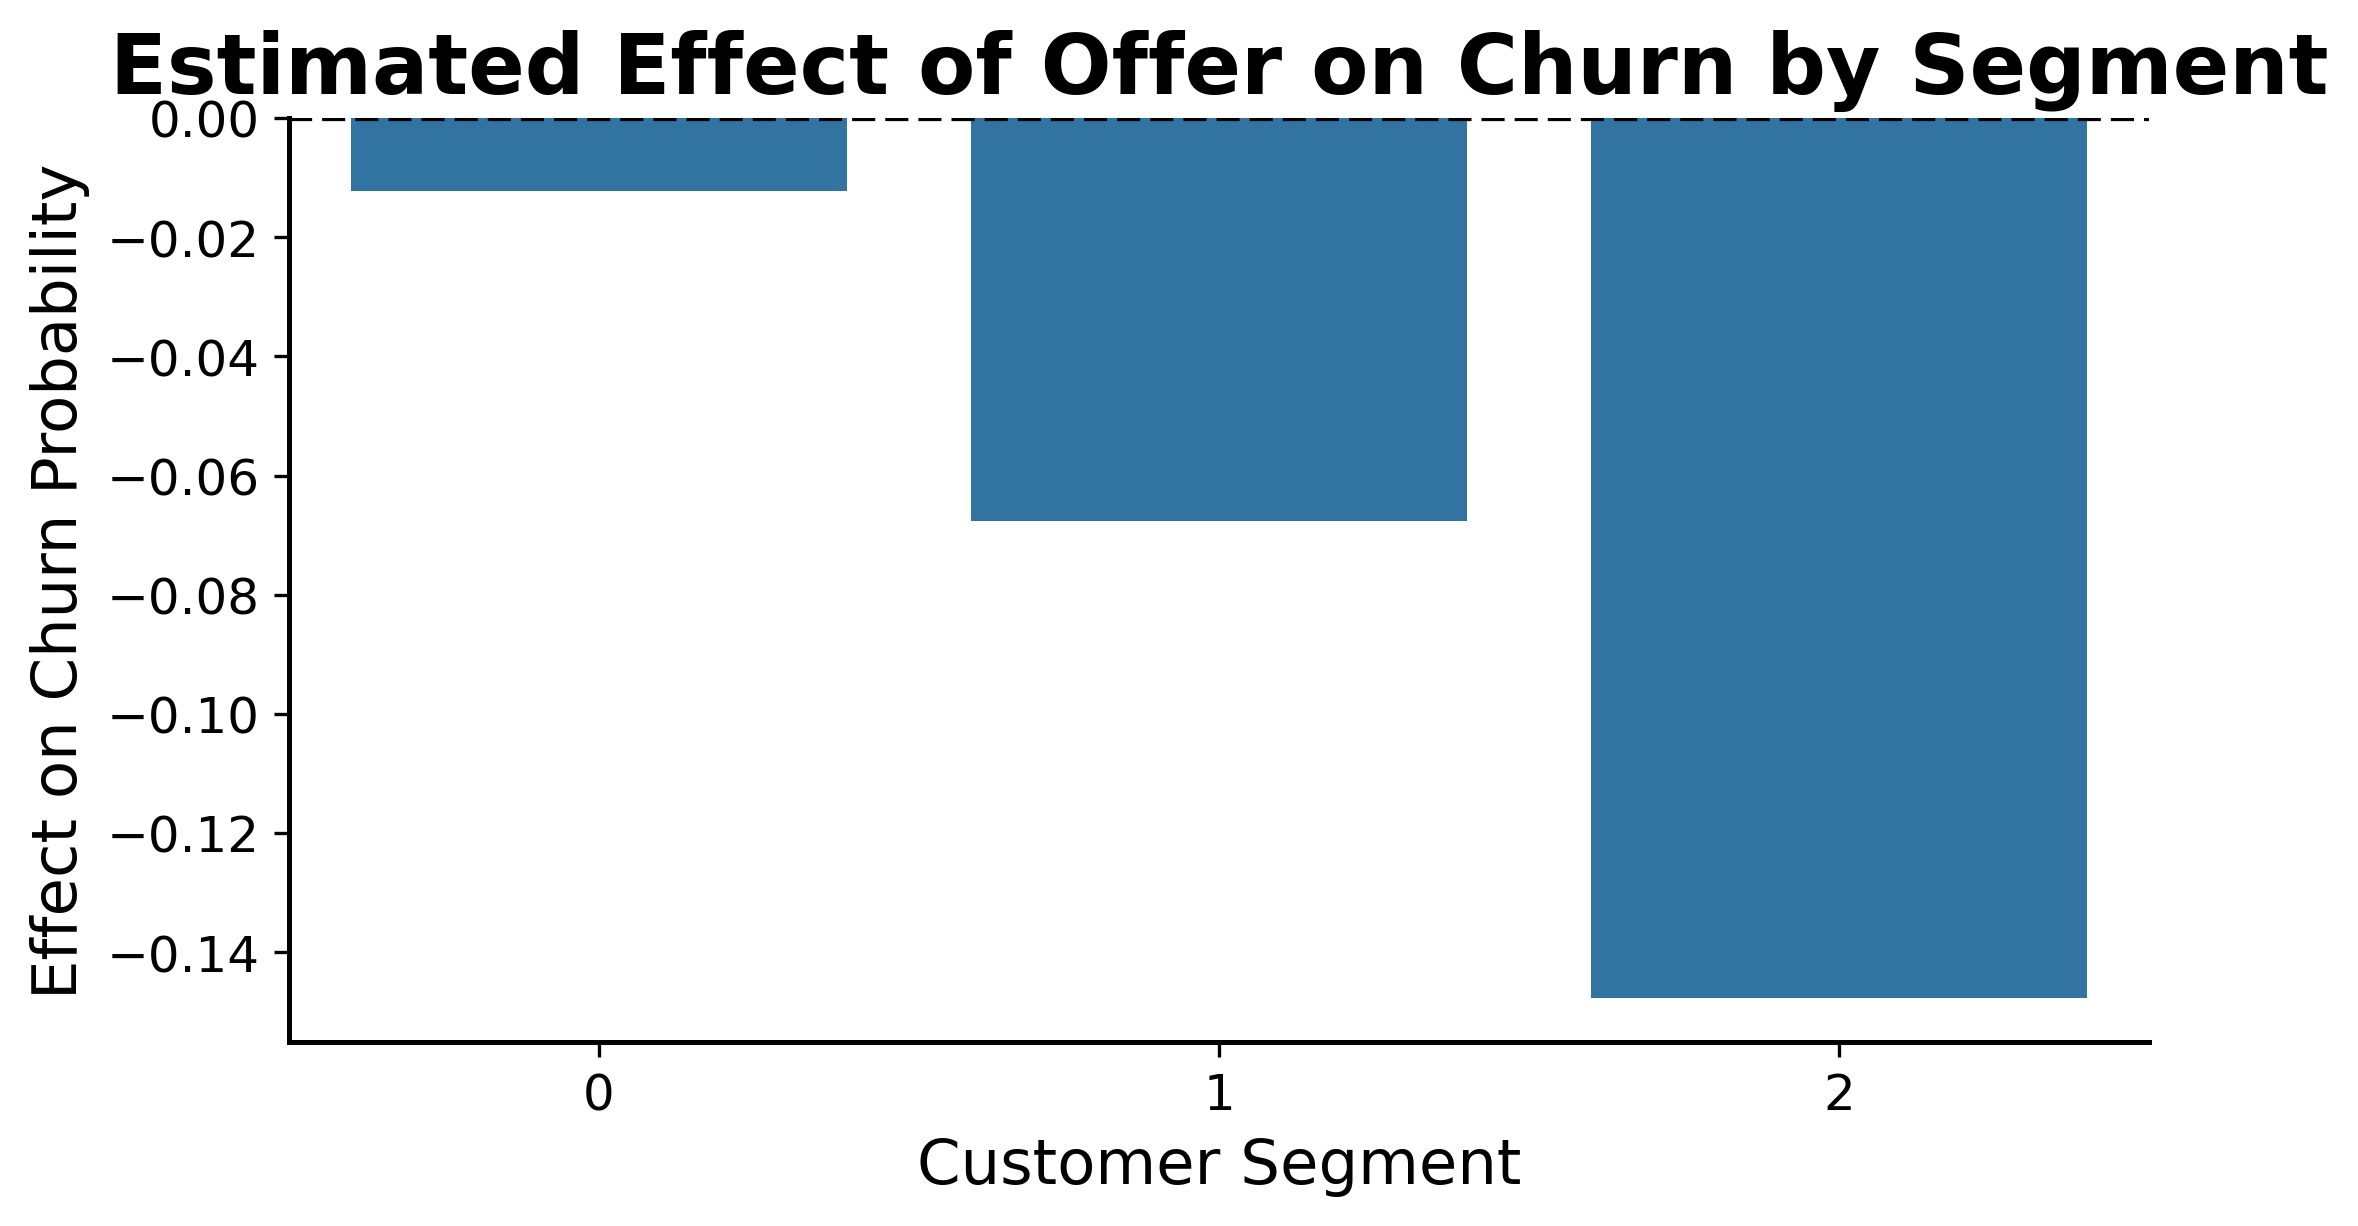

In [166]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=dowhy_results,
    x="Segment",
    y="DoWhy_Effect"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Estimated Effect of Offer on Churn by Segment")
plt.ylabel("Effect on Churn Probability")
plt.xlabel("Customer Segment")
plt.show()

In [167]:
roi_rows = []

for seg in sorted(df["Customer_Segment"].unique()):
    seg_df = df[df["Customer_Segment"] == seg].copy()
    treated_df = seg_df[seg_df[TREATMENT] == 1].copy()

    seg_name = segment_name_map.get(seg, f"Segment {seg}")

    n_customers = len(seg_df)
    n_treated = len(treated_df)

    dowhy_effect = dowhy_results.loc[
        dowhy_results["Segment"] == seg,
        "DoWhy_Effect"
    ].values

    dowhy_effect = dowhy_effect[0] if len(dowhy_effect) > 0 else np.nan

    # Negative treatment effect means churn reduction.
    estimated_churn_reduction_rate = max(-dowhy_effect, 0) if pd.notna(dowhy_effect) else np.nan

    estimated_churns_prevented = (
        estimated_churn_reduction_rate * n_treated
        if pd.notna(estimated_churn_reduction_rate)
        else np.nan
    )

    avg_customer_value = (
        treated_df["Customer_Value"].mean()
        if "Customer_Value" in treated_df.columns
        else np.nan
    )

    total_offer_cost = (
        treated_df["Offer_Cost"].sum()
        if "Offer_Cost" in treated_df.columns
        else np.nan
    )

    estimated_revenue_saved = (
        estimated_churns_prevented * avg_customer_value
        if pd.notna(estimated_churns_prevented) and pd.notna(avg_customer_value)
        else np.nan
    )

    estimated_net_value = (
        estimated_revenue_saved - total_offer_cost
        if pd.notna(estimated_revenue_saved) and pd.notna(total_offer_cost)
        else np.nan
    )

    estimated_roi = (
        estimated_net_value / total_offer_cost
        if pd.notna(estimated_net_value) and pd.notna(total_offer_cost) and total_offer_cost != 0
        else np.nan
    )

    row = {
        "Customer_Segment": seg,
        "Segment_Name": seg_name,
        "Customers": n_customers,
        "Treated_Customers": n_treated,
        "Offer_Rate": n_treated / n_customers if n_customers > 0 else np.nan,
        "Churn_Rate": seg_df[OUTCOME].mean(),
        "DoWhy_Effect": dowhy_effect,
        "Estimated_Churn_Reduction_Rate": estimated_churn_reduction_rate,
        "Estimated_Churns_Prevented": estimated_churns_prevented,
        "Avg_Customer_Value_Treated": avg_customer_value,
        "Total_Offer_Cost": total_offer_cost,
        "Estimated_Revenue_Saved": estimated_revenue_saved,
        "Estimated_Net_Value": estimated_net_value,
        "Estimated_ROI": estimated_roi
    }

    if "Expected_Revenue_Saved" in treated_df.columns:
        row["Simulated_Expected_Revenue_Saved"] = treated_df["Expected_Revenue_Saved"].sum()

    if "Expected_Net_Value" in treated_df.columns:
        row["Simulated_Expected_Net_Value"] = treated_df["Expected_Net_Value"].sum()

    roi_rows.append(row)

segment_roi = pd.DataFrame(roi_rows)

money_cols = [
    "Avg_Customer_Value_Treated",
    "Total_Offer_Cost",
    "Estimated_Revenue_Saved",
    "Estimated_Net_Value",
    "Simulated_Expected_Revenue_Saved",
    "Simulated_Expected_Net_Value"
]

for c in money_cols:
    if c in segment_roi.columns:
        segment_roi[c] = segment_roi[c].round(2)

rate_cols = [
    "Offer_Rate",
    "Churn_Rate",
    "DoWhy_Effect",
    "Estimated_Churn_Reduction_Rate",
    "Estimated_ROI"
]

for c in rate_cols:
    if c in segment_roi.columns:
        segment_roi[c] = segment_roi[c].round(4)

segment_roi["Estimated_Churns_Prevented"] = segment_roi["Estimated_Churns_Prevented"].round(2)

display(segment_roi)

,Customer_Segment,Segment_Name,Customers,Treated_Customers,Offer_Rate,Churn_Rate,DoWhy_Effect,Estimated_Churn_Reduction_Rate,Estimated_Churns_Prevented,Avg_Customer_Value_Treated,Total_Offer_Cost,Estimated_Revenue_Saved,Estimated_Net_Value,Estimated_ROI,Simulated_Expected_Revenue_Saved,Simulated_Expected_Net_Value
0,0,Growth Customers,1593,521,0.3271,0.0753,-0.0122,0.0122,6.36,350.00,5210.0,2224.67,-2985.33,-0.5730,6754.37,1544.37
1,1,Budget Stable Customers,2292,1091,0.4760,0.1750,-0.0676,0.0676,73.75,619.75,10910.0,45707.74,34797.74,3.1895,75039.82,64129.82
2,2,Premium At-Risk Customers,3158,2348,0.7435,0.3331,-0.1477,0.1477,346.80,537.05,23480.0,186249.70,162769.70,6.9323,265818.50,242338.50


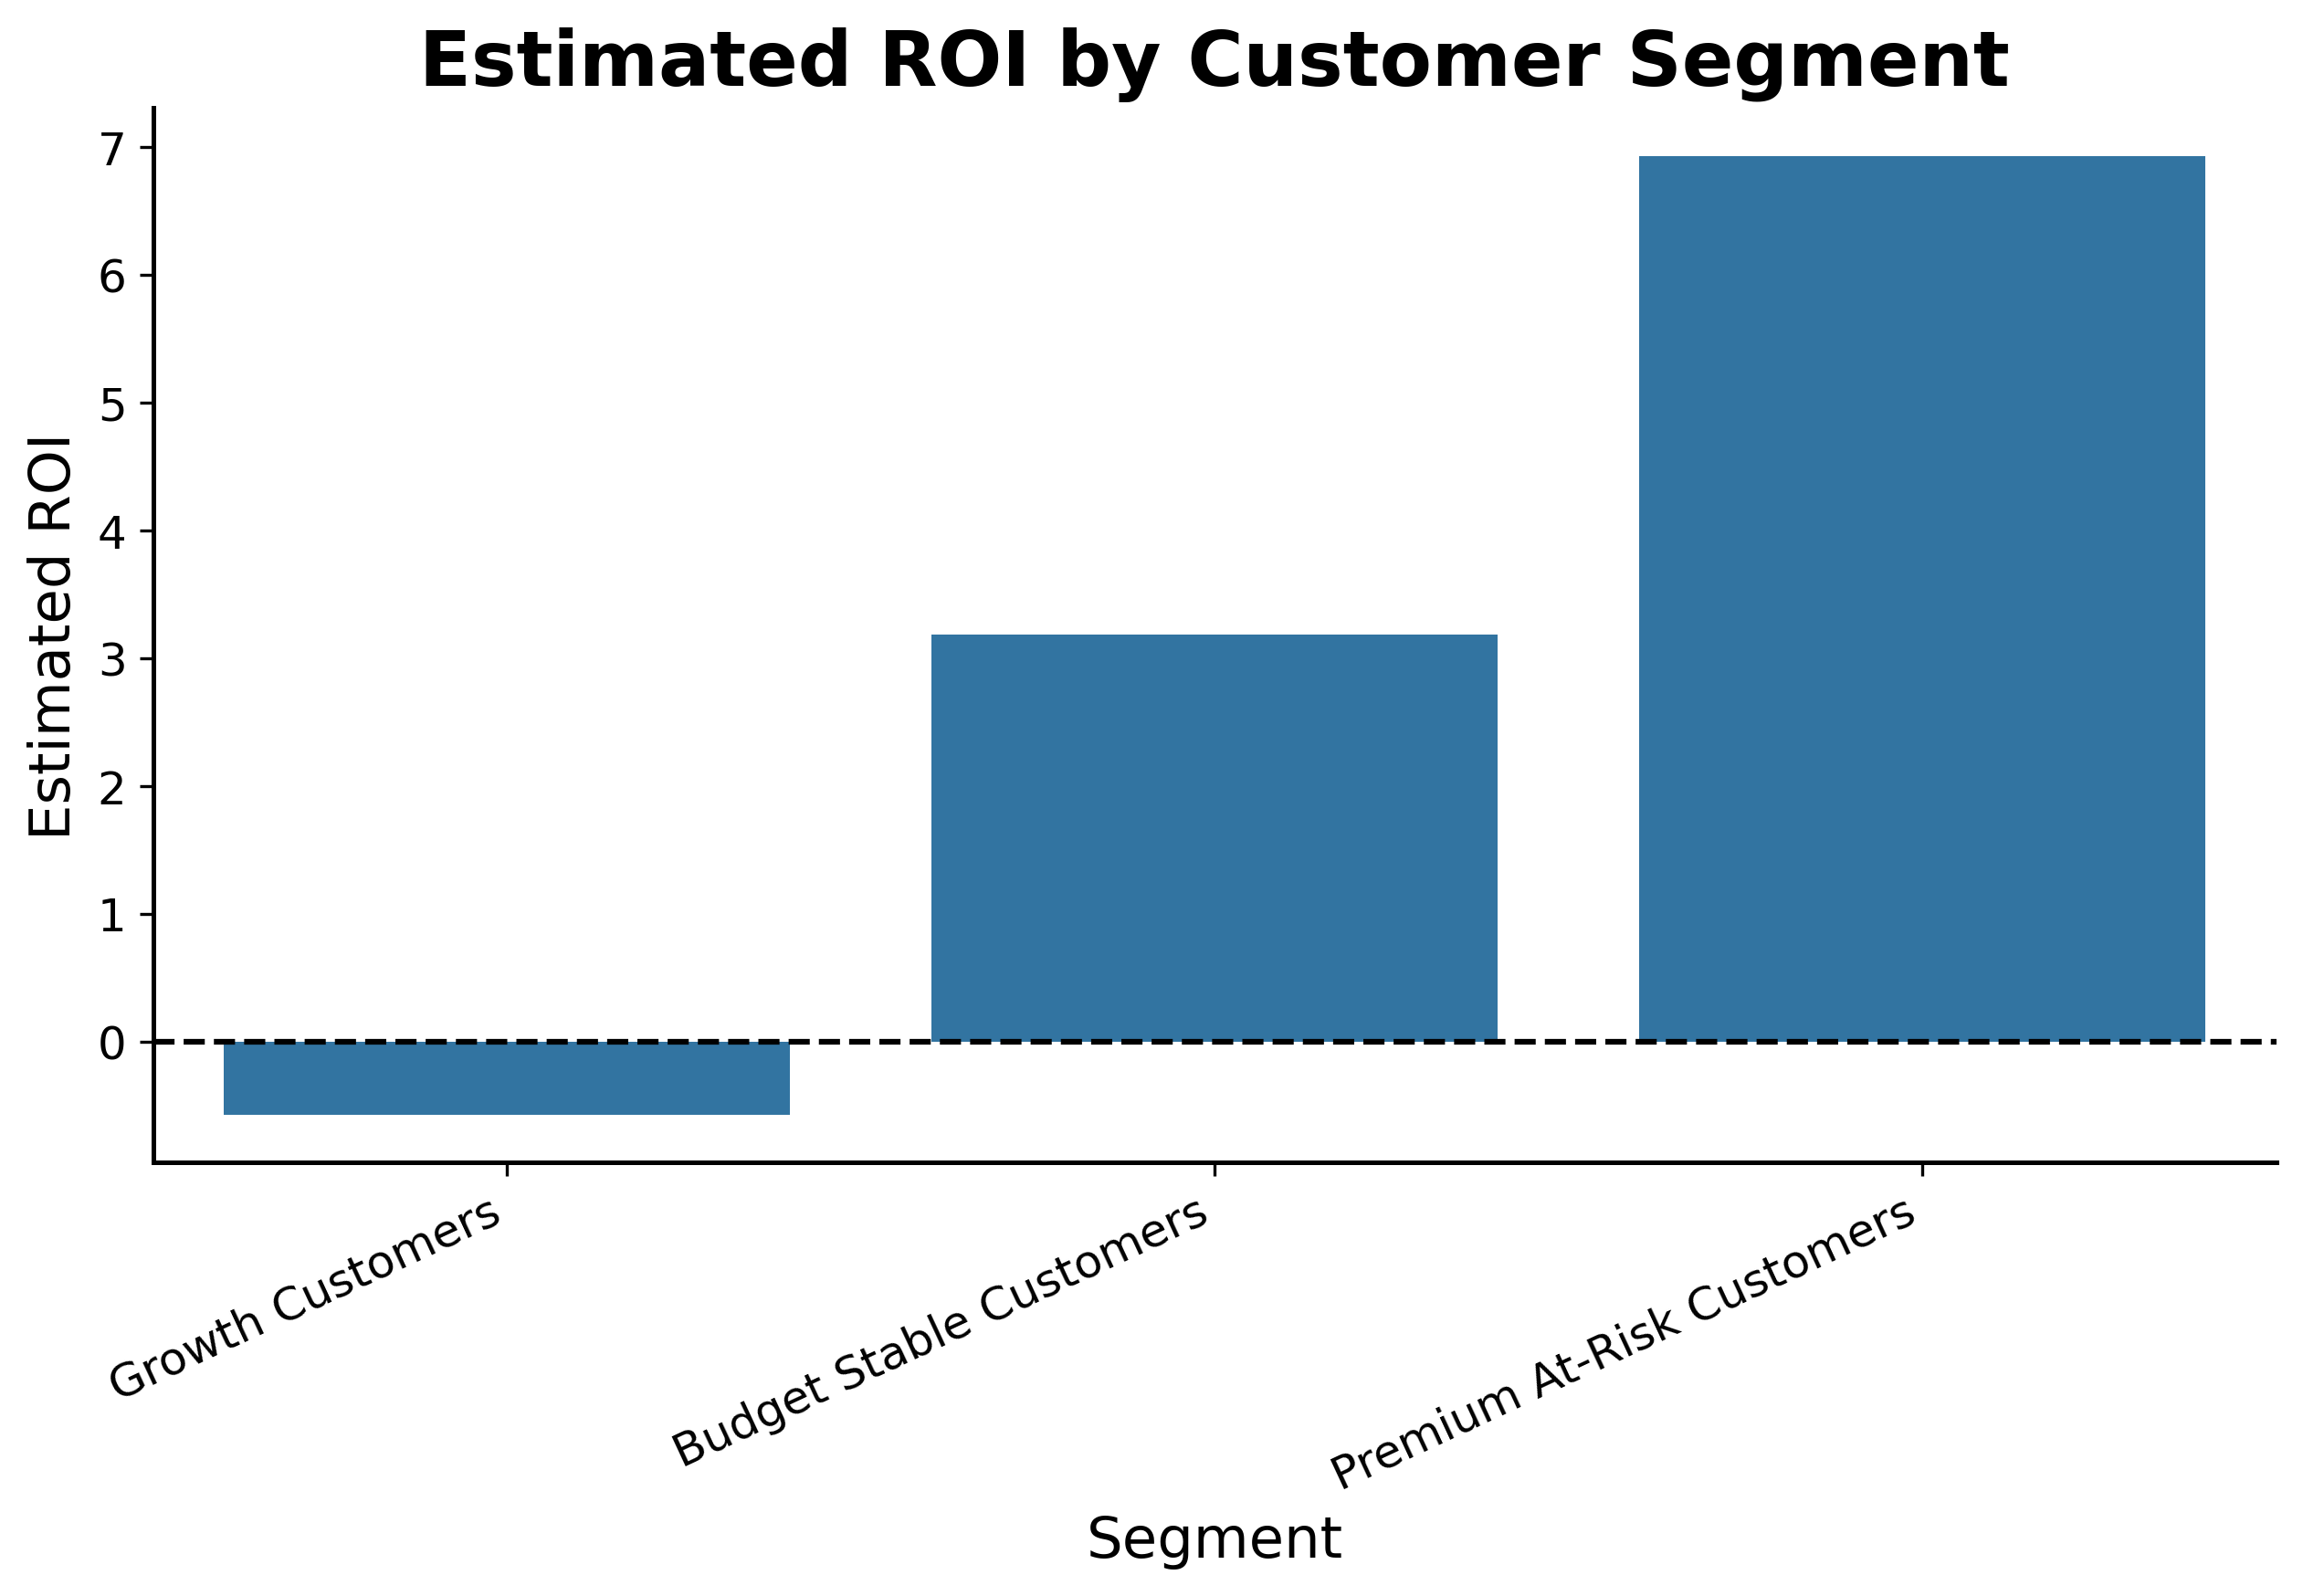

In [168]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_roi,
    x="Segment_Name",
    y="Estimated_ROI"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Estimated ROI by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Estimated ROI")
plt.xticks(rotation=25, ha="right")
plt.show()

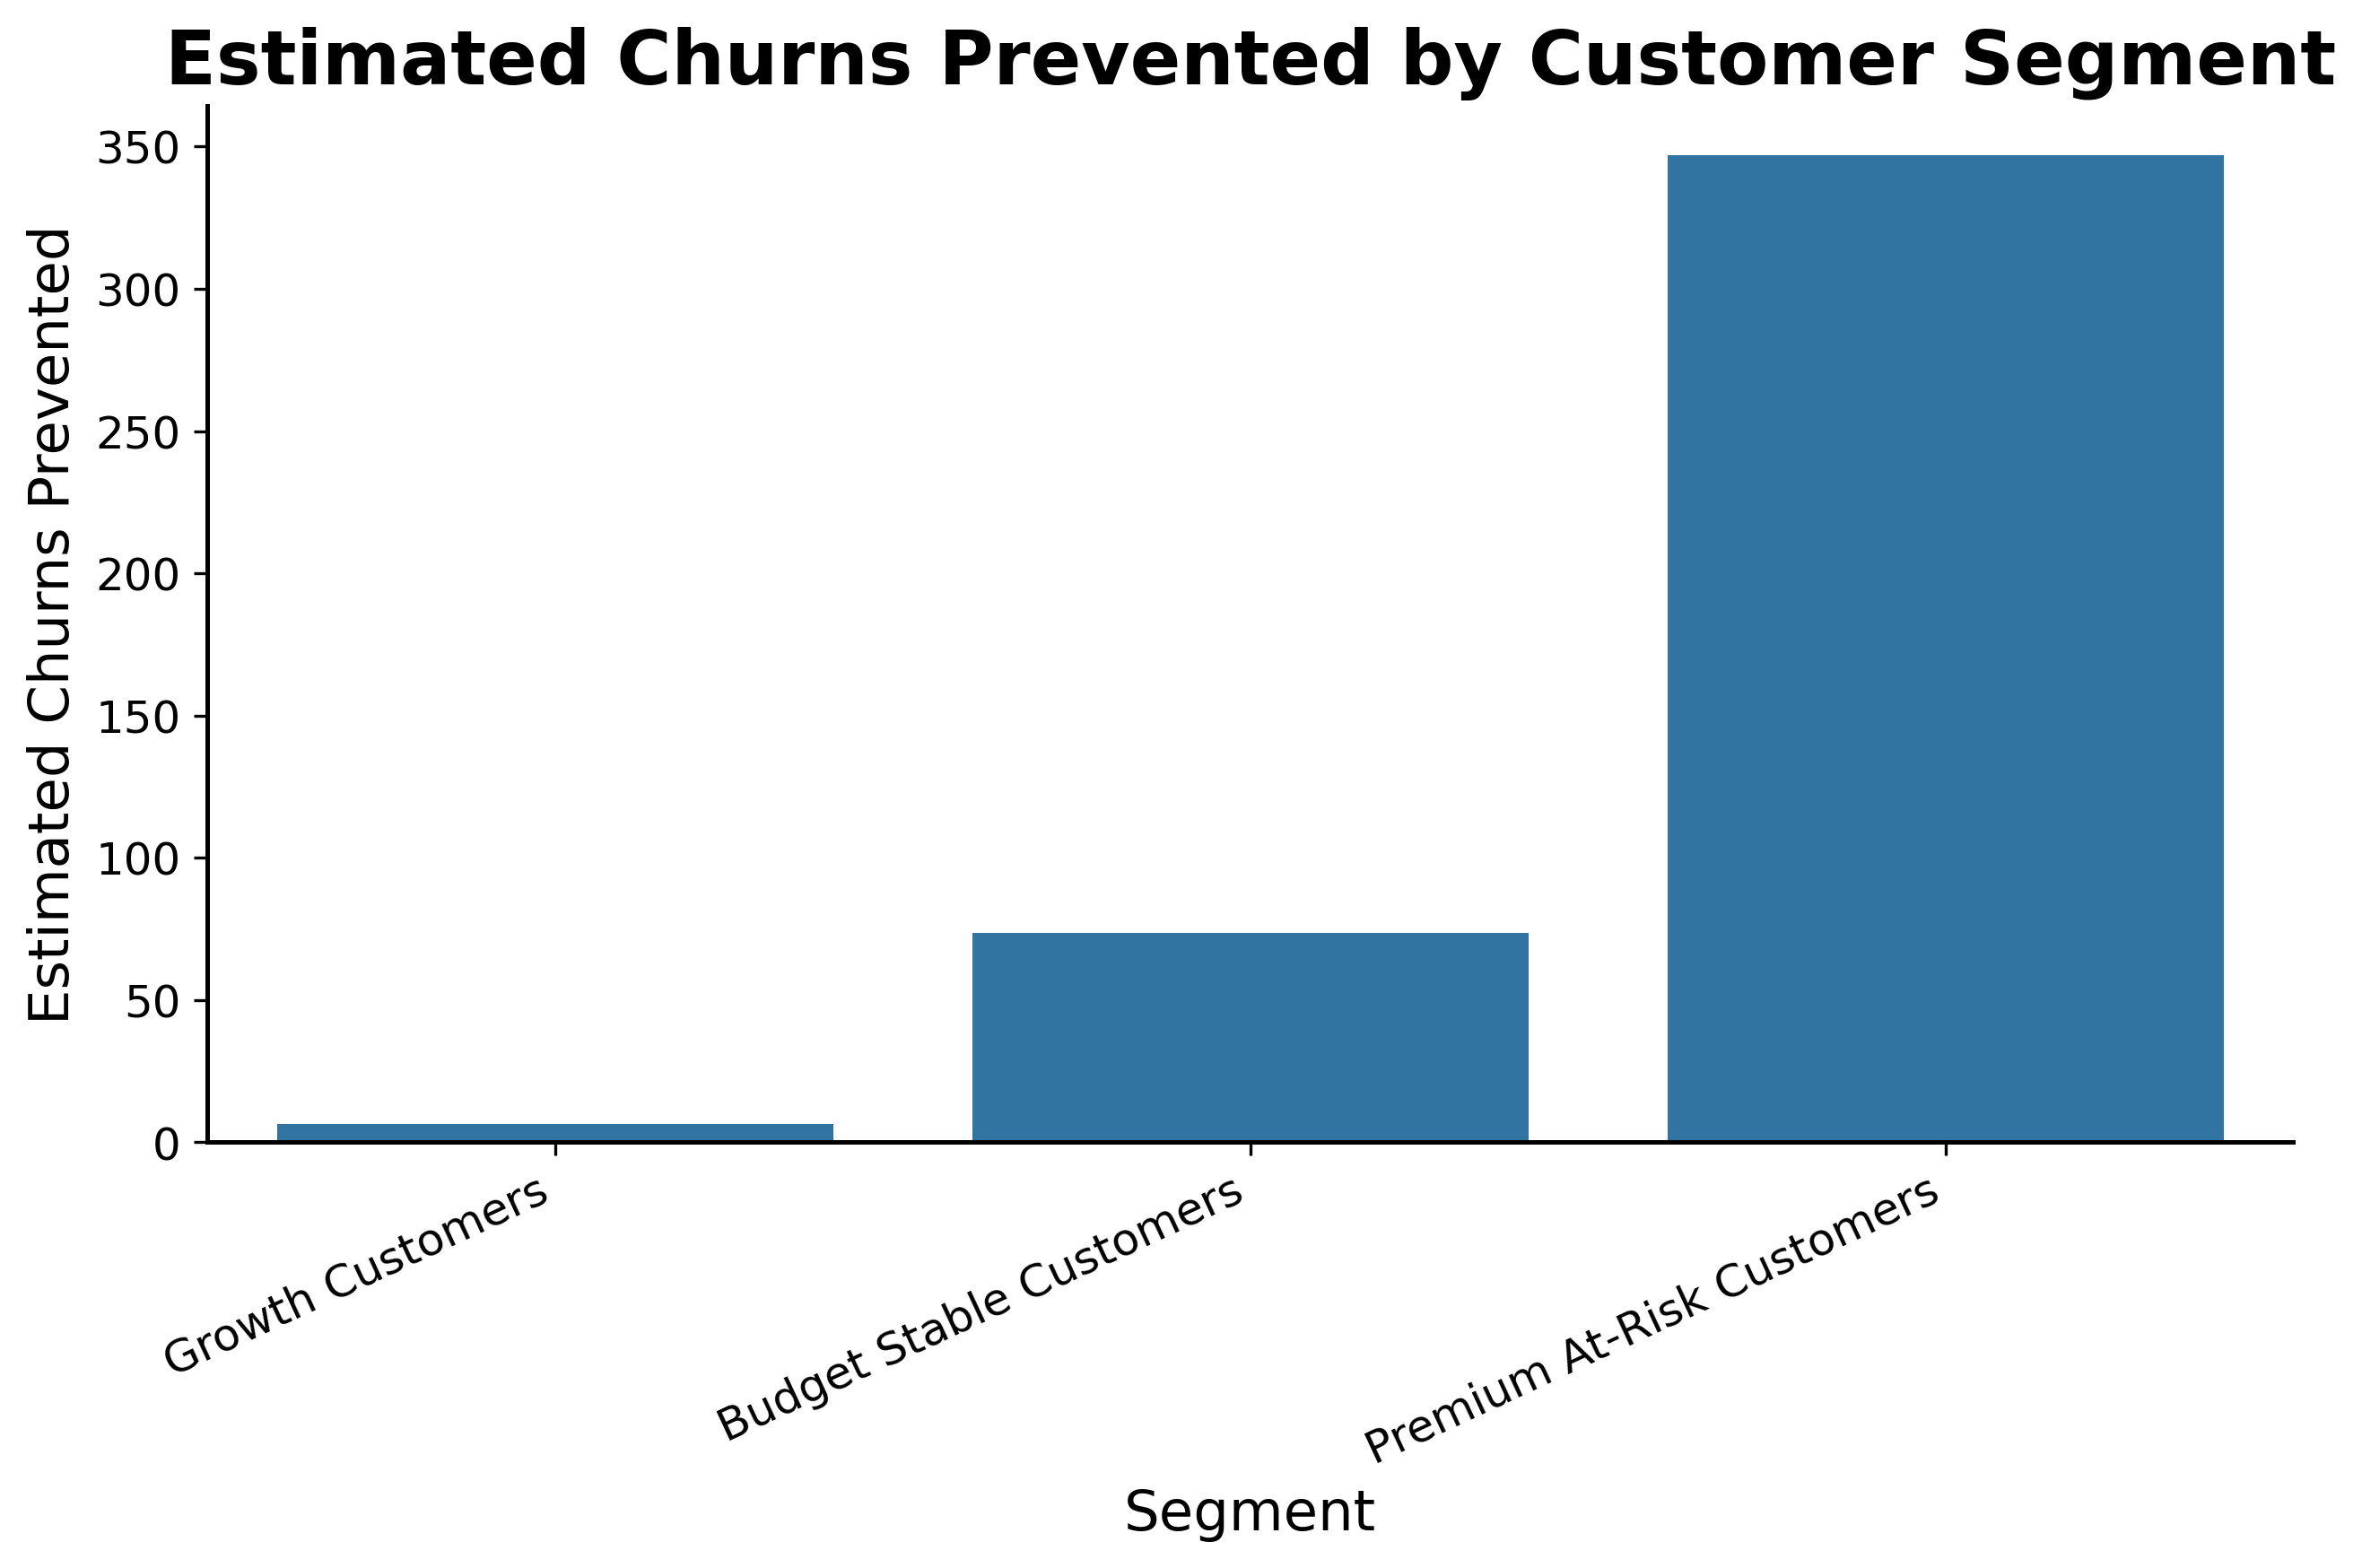

In [169]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_roi,
    x="Segment_Name",
    y="Estimated_Churns_Prevented"
)

plt.title("Estimated Churns Prevented by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Estimated Churns Prevented")
plt.xticks(rotation=25, ha="right")
plt.show()

In [170]:
roi_recommendation = (
    segment_roi
    .sort_values("Estimated_ROI", ascending=False)
    .reset_index(drop=True)
)

display(roi_recommendation)

,Customer_Segment,Segment_Name,Customers,Treated_Customers,Offer_Rate,Churn_Rate,DoWhy_Effect,Estimated_Churn_Reduction_Rate,Estimated_Churns_Prevented,Avg_Customer_Value_Treated,Total_Offer_Cost,Estimated_Revenue_Saved,Estimated_Net_Value,Estimated_ROI,Simulated_Expected_Revenue_Saved,Simulated_Expected_Net_Value
0,2,Premium At-Risk Customers,3158,2348,0.7435,0.3331,-0.1477,0.1477,346.80,537.05,23480.0,186249.70,162769.70,6.9323,265818.50,242338.50
1,1,Budget Stable Customers,2292,1091,0.4760,0.1750,-0.0676,0.0676,73.75,619.75,10910.0,45707.74,34797.74,3.1895,75039.82,64129.82
2,0,Growth Customers,1593,521,0.3271,0.0753,-0.0122,0.0122,6.36,350.00,5210.0,2224.67,-2985.33,-0.5730,6754.37,1544.37


In [171]:
truth_cols = [
    "True_Propensity",
    "Churn_Probability_No_Offer",
    "Churn_Probability_With_Offer",
    "True_Treatment_Effect"
]

truth_cols = [c for c in truth_cols if c in df.columns]

if truth_cols:
    truth_check = (
        df
        .groupby("Customer_Segment")[truth_cols]
        .mean()
        .round(4)
    )

    display(truth_check)

,True_Propensity,Churn_Probability_No_Offer,Churn_Probability_With_Offer,True_Treatment_Effect
Customer_Segment,,,,
0,0.3033,0.0772,0.0518,-0.0253
1,0.4840,0.2278,0.1605,-0.0673
2,0.7407,0.4749,0.3009,-0.1740
